# PokerProject2: Commercial Behavioral Analytics from Gameplay Logs

## Executive Summary

This project converts imperfect PHH gameplay logs into a commercial analytics case study. The focus is not poker strategy; it is participant behavior, contest lifecycle depth, interaction intensity, resolution visibility, and outcome concentration.

The strongest finding is that action-level event data can support useful product analytics even when private-card visibility is incomplete. The notebook therefore emphasizes observable behavior and explicitly separates reliable event metrics from weaker card-strength or strategy claims.

In practical terms, the workflow shows how an analyst can audit messy data, define business-readable metrics, test data limitations, and translate gameplay logs into product and ecosystem insights.


## Business Question

How can raw gameplay logs be transformed into metrics that help a gaming, sportsbook, fantasy, or contest operator understand participant behavior and product experience?

This analysis focuses on five practical questions:

- How much interaction does a typical hand create?
- Which hands generate higher-commitment action?
- How far through the contest lifecycle do hands progress before resolving?
- Is outcome intensity concentrated in a small share of hands?
- How much of the underlying event data is visible enough to support stronger conclusions?


## Methodology and Data Flow

The notebook follows a simple analytics workflow:

1. Audit available files and separate single-hand `.phh` records from multi-hand `.phhs` containers.
2. Parse the single-hand PHH files into a flat hand-level table.
3. Derive observable behavioral metrics such as action depth, high-commitment action rate, lifecycle stage, resolution path, and outcome intensity.
4. Validate card visibility and obfuscation before making any claims that depend on private cards.
5. Translate the metrics into commercial takeaways that would make sense to non-poker stakeholders.

The `.phhs` HandHQ files are real multi-hand containers and can be read with `HandHistory.load_all()`. They are audited here but kept outside the main analysis so the primary dataset remains one row per single-hand file.


## Load PHH Files and Audit Source Coverage

            The notebook expects the PHH files to live in the local `data` folder inside this project. The audit below confirms how many files are available by source folder before any behavioral analysis is run.


In [1]:
from pathlib import Path
import re
import pandas as pd
import numpy as np
from tqdm import tqdm

# Install only if needed
try:
    from pokerkit import HandHistory
except ModuleNotFoundError:
    import sys
    !{sys.executable} -m pip install pokerkit
    from pokerkit import HandHistory

# Resolve the project folder relative to the notebook when possible.
# This supports running either from the repository root or from notebooks/.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = Path.home() / "Downloads" / "poker-hand-histories"
PHH_ROOT = PROJECT_ROOT / "data"

candidate_files = sorted(
    path
    for path in PHH_ROOT.rglob("*")
    if path.is_file() and path.suffix.lower() in {".phh", ".phhs"}
)

# The core analysis below uses one row per single-hand .phh file. The HandHQ
# folder uses .phhs multi-hand containers, which PokerKit can read with
# HandHistory.load_all(). They are audited here but excluded from the main
# analysis to avoid mixing two different units of observation.
phh_files = sorted(path for path in candidate_files if path.suffix.lower() == ".phh")
phhs_files = sorted(path for path in candidate_files if path.suffix.lower() == ".phhs")

def source_folder(path):
    path = Path(path)
    rel = path.relative_to(PHH_ROOT)
    return rel.parts[0] if len(rel.parts) > 1 else "root_examples"

file_inventory = pd.DataFrame([
    {
        "source_folder": source_folder(path),
        "extension": path.suffix.lower(),
        "included_in_main_analysis": path.suffix.lower() == ".phh",
    }
    for path in candidate_files
])

dataset_audit = (
    file_inventory
    .groupby(["source_folder", "extension", "included_in_main_analysis"], as_index=False)
    .size()
    .rename(columns={"size": "files"})
    .sort_values(["included_in_main_analysis", "source_folder", "extension"], ascending=[False, True, True])
)

print(PROJECT_ROOT)
print(PHH_ROOT)
print("Exists?", PHH_ROOT.exists())
print(f"Found {len(candidate_files):,} PHH/PHHS candidate files")
print(f"Using {len(phh_files):,} single-hand .phh files in the main analysis")
print(f"Excluding {len(phhs_files):,} .phhs multi-hand container files from the main analysis")

phhs_sample_hand_count = np.nan
if phhs_files:
    import warnings
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            with open(phhs_files[0], "rb") as f:
                phhs_sample_hand_count = sum(1 for _ in HandHistory.load_all(f))
        print(f"Sample .phhs container loads {phhs_sample_hand_count:,.0f} hands via HandHistory.load_all()")
    except Exception as e:
        print(f"Sample .phhs load_all check failed: {e}")

display(dataset_audit)


C:\Users\J1999\Downloads\poker-hand-histories
C:\Users\J1999\Downloads\poker-hand-histories\data
Exists? True
Found 31,870 PHH/PHHS candidate files
Using 10,088 single-hand .phh files in the main analysis
Excluding 21,782 .phhs multi-hand container files from the main analysis


Sample .phhs container loads 999 hands via HandHistory.load_all()


,source_folder,extension,included_in_main_analysis,files
1,pluribus,.phh,True,10000
2,root_examples,.phh,True,5
3,wsop,.phh,True,83
0,handhq,.phhs,False,21782


## Reusable Parsing Helpers

The reusable layer below keeps parsing, card visibility checks, outcome extraction, participant-row creation, and obfuscation validation in one place. Later sections call these helpers instead of redefining the same loading and action-parsing logic.


In [2]:
CARD_RE = re.compile(r"\b[2-9TJQKA][cdhs]\b", re.IGNORECASE)
DECISION_CODES = {"f", "cc", "cbr"}
DEAL_CODES = {"dh", "db"}


def source_type_detailed_from_folder(folder):
    if folder == "pluribus":
        return "Pluribus (AI benchmark)"
    if folder == "wsop":
        return "WSOP mixed-game sample"
    if folder == "handhq":
        return "HandHQ multi-hand containers"
    if folder == "root_examples":
        return "Reference examples"
    return "Other / Unknown"


def parse_path_metadata(path):
    path = Path(path)
    path_str = str(path).replace("\\", "/").lower()
    parts = list(path.parts)

    try:
        folder = source_folder(path)
    except Exception:
        folder = "unknown"

    is_wsop = folder == "wsop" or "/wsop/" in path_str
    is_pluribus = folder == "pluribus" or "/pluribus/" in path_str
    is_handhq = folder == "handhq" or "/handhq/" in path_str
    folder_year = None
    event_id = None
    table_id = None

    if is_wsop:
        try:
            parts_lower = [p.lower() for p in parts]
            wsop_idx = parts_lower.index("wsop")
            folder_year = int(parts[wsop_idx + 1])
            event_id = parts[wsop_idx + 2] if len(parts) > wsop_idx + 2 else None
            table_id = parts[wsop_idx + 3] if len(parts) > wsop_idx + 3 else None
        except Exception:
            pass

    return {
        "source_folder": folder,
        "source_type_detailed": source_type_detailed_from_folder(folder),
        "is_wsop": is_wsop,
        "is_pluribus": is_pluribus,
        "is_handhq": is_handhq,
        "folder_year": folder_year,
        "event_id": event_id,
        "table_id": table_id,
    }


def load_hand(path):
    with open(Path(path), "rb") as f:
        return HandHistory.load(f)


def safe_len(x):
    try:
        return len(x)
    except Exception:
        return np.nan


def to_list(x):
    return list(x) if isinstance(x, (list, tuple)) else []


def numeric_values(x):
    return [v for v in to_list(x) if isinstance(v, (int, float))]


def safe_sum_numeric(x):
    vals = numeric_values(x)
    return sum(vals) if vals else np.nan


def get_attr(obj, name, default=None):
    return getattr(obj, name, default)


def hand_actions(hh):
    return [str(a).lower().strip() for a in to_list(get_attr(hh, "actions", []))]


def action_code(action):
    parts = str(action).lower().strip().split()
    if len(parts) >= 2 and parts[0].startswith("p"):
        return parts[1]
    if len(parts) >= 2 and parts[0] == "d":
        return parts[1]
    return None


def actor_index(action):
    parts = str(action).lower().strip().split()
    if parts and parts[0].startswith("p"):
        try:
            return int(parts[0][1:]) - 1
        except ValueError:
            return None
    return None


def cards_in_action(action):
    return [c.lower() for c in CARD_RE.findall(str(action))]


def hand_action_metrics(hh):
    actions = hand_actions(hh)
    codes = [action_code(a) for a in actions]
    num_actions = len(actions)

    if not actions:
        return {
            "num_actions": np.nan,
            "num_player_decisions": np.nan,
            "num_deal_events": np.nan,
            "num_hole_deals": np.nan,
            "num_board_deals": np.nan,
            "num_folds": np.nan,
            "num_calls_checks": np.nan,
            "num_bets_raises": np.nan,
            "num_posts": np.nan,
            "num_showdown_like": np.nan,
            "bet_raise_rate": np.nan,
            "decision_bet_raise_rate": np.nan,
            "fold_rate": np.nan,
            "decision_fold_rate": np.nan,
        }

    num_folds = sum(code == "f" for code in codes)
    num_calls_checks = sum(code == "cc" for code in codes)
    num_bets_raises = sum(code == "cbr" for code in codes)
    num_player_decisions = sum(code in DECISION_CODES for code in codes)
    num_deal_events = sum(code in DEAL_CODES for code in codes)
    num_hole_deals = sum(code == "dh" for code in codes)
    num_board_deals = sum(code == "db" for code in codes)
    num_posts = sum(code in {"pb", "p"} for code in codes)
    num_showdown_like = sum(code in {"sm", "sd"} or "show" in a or "muck" in a for code, a in zip(codes, actions))

    return {
        "num_actions": num_actions,
        "num_player_decisions": num_player_decisions,
        "num_deal_events": num_deal_events,
        "num_hole_deals": num_hole_deals,
        "num_board_deals": num_board_deals,
        "num_folds": num_folds,
        "num_calls_checks": num_calls_checks,
        "num_bets_raises": num_bets_raises,
        # Retained as a diagnostic column only. Most PHH actions in this corpus
        # encode forced commitments through structured fields, not player post actions.
        "num_posts": num_posts,
        "num_showdown_like": num_showdown_like,
        "bet_raise_rate": num_bets_raises / num_actions if num_actions else np.nan,
        "decision_bet_raise_rate": num_bets_raises / num_player_decisions if num_player_decisions else np.nan,
        "fold_rate": num_folds / num_actions if num_actions else np.nan,
        "decision_fold_rate": num_folds / num_player_decisions if num_player_decisions else np.nan,
    }


def hand_street_metrics(hh):
    actions = hand_actions(hh)
    streets = {"preflop": [], "flop": [], "turn": [], "river": []}
    board_deals = 0
    street_map = {0: "preflop", 1: "flop", 2: "turn", 3: "river"}

    for action in actions:
        code = action_code(action)
        if code == "db":
            board_deals += 1
            continue
        if code in DECISION_CODES:
            street = street_map.get(min(board_deals, 3), "river")
            streets[street].append(code)

    def street_stats(codes):
        n = len(codes)
        bets_raises = sum(code == "cbr" for code in codes)
        folds = sum(code == "f" for code in codes)
        calls_checks = sum(code == "cc" for code in codes)
        return {
            "decisions": n,
            "bets_raises": bets_raises,
            "folds": folds,
            "calls_checks": calls_checks,
            "bet_raise_rate": bets_raises / n if n else np.nan,
            "fold_rate": folds / n if n else np.nan,
        }

    result = {}
    for street, codes in streets.items():
        for metric, value in street_stats(codes).items():
            result[f"{street}_{metric}"] = value

    result["reached_flop"] = board_deals >= 1
    result["reached_turn"] = board_deals >= 2
    result["reached_river"] = board_deals >= 3
    return result


def chips_contested_from_net_changes(net_changes):
    vals = [x for x in to_list(net_changes) if isinstance(x, (int, float))]
    positives = [x for x in vals if x > 0]
    if not positives:
        return np.nan
    return sum(positives)


def card_visibility_metrics(hh):
    actions = hand_actions(hh)
    known_cards = []
    unknown_token_count = 0
    show_muck_actions = 0
    known_show_muck_actions = 0

    for action in actions:
        cards = cards_in_action(action)
        known_cards.extend(cards)
        unknown_token_count += action.count("?")

        code = action_code(action)
        is_show_muck = code in {"sm", "sd"} or "show" in action or "muck" in action
        if is_show_muck:
            show_muck_actions += 1
            known_show_muck_actions += int(bool(cards))

    return {
        "has_actions": bool(actions),
        "known_card_count": len(known_cards),
        "unknown_card_token_count": unknown_token_count,
        "has_known_cards": len(known_cards) > 0,
        "has_unknown_cards": unknown_token_count > 0,
        "show_muck_actions": show_muck_actions,
        "known_show_muck_actions": known_show_muck_actions,
        "known_cards": known_cards if known_cards else None,
    }


def stack_net_changes(starting_stacks, finishing_stacks):
    starting = numeric_values(starting_stacks)
    finishing = numeric_values(finishing_stacks)
    if len(starting) == len(finishing) and starting:
        return [finish - start for start, finish in zip(starting, finishing)]
    return []


def parse_card_visibility(path):
    path = Path(path)

    try:
        hh = load_hand(path)
        row = {
            "file": str(path),
            "filename": path.name,
            "parse_success": True,
            "variant": get_attr(hh, "variant", None),
            "year": get_attr(hh, "year", None),
            "num_players": safe_len(get_attr(hh, "players", [])),
            "num_actions": len(hand_actions(hh)),
        }
        row.update(parse_path_metadata(path))
        row.update(card_visibility_metrics(hh))
        return row

    except Exception as e:
        return {
            "file": str(path),
            "filename": path.name,
            "parse_success": False,
            "parse_error": str(e)[:200],
        }


def parse_winner_outcome(path):
    path = Path(path)

    try:
        hh = load_hand(path)
    except Exception as e:
        return {
            "file": str(path),
            "filename": path.name,
            "parse_success": False,
            "parse_error": str(e)[:200],
        }

    players = to_list(get_attr(hh, "players", []))
    actions = hand_actions(hh)
    num_players = len(players)

    net_changes = stack_net_changes(
        get_attr(hh, "starting_stacks", None),
        get_attr(hh, "finishing_stacks", None),
    )

    if not net_changes:
        winnings = numeric_values(get_attr(hh, "winnings", None))
        if len(winnings) == num_players:
            net_changes = winnings

    max_net = max(net_changes) if net_changes else None
    winner_indices = [
        i for i, value in enumerate(net_changes)
        if max_net is not None and value == max_net and value > 0
    ]
    winner_names = [players[i] for i in winner_indices if i < len(players)]
    winner_tokens = {f"p{i + 1}" for i in winner_indices}

    known_cards_by_player = {f"p{i + 1}": [] for i in range(num_players)}
    show_muck_by_player = {f"p{i + 1}": 0 for i in range(num_players)}

    for action in actions:
        cards = cards_in_action(action)
        code = action_code(action)
        tokens = set(action.split())

        for token in known_cards_by_player:
            if token in tokens:
                show_muck_by_player[token] += int(code in {"sm", "sd"} or "show" in action or "muck" in action)
                if cards:
                    known_cards_by_player[token].extend(cards)

    winner_known_cards = [
        card
        for token in winner_tokens
        for card in known_cards_by_player.get(token, [])
    ]
    winner_show_muck_actions = sum(show_muck_by_player.get(token, 0) for token in winner_tokens)

    action_metrics = hand_action_metrics(hh)
    street_metrics = hand_street_metrics(hh)
    visibility_metrics = card_visibility_metrics(hh)
    chips_contested_proxy = chips_contested_from_net_changes(net_changes)

    return {
        "file": str(path),
        "filename": path.name,
        "parse_success": True,
        "variant": get_attr(hh, "variant", None),
        "currency": get_attr(hh, "currency", None),
        "year": get_attr(hh, "year", None),
        "players": players,
        "num_players": num_players,
        "starting_stacks": get_attr(hh, "starting_stacks", None),
        "finishing_stacks": get_attr(hh, "finishing_stacks", None),
        "winnings": get_attr(hh, "winnings", None),
        "net_changes": net_changes,
        "chips_contested_proxy": chips_contested_proxy,
        "winner_indices": winner_indices,
        "winner_names": winner_names,
        "num_winners": len(winner_indices),
        "winner_known_cards": winner_known_cards if winner_known_cards else None,
        "winner_known_card_count": len(winner_known_cards),
        "winner_has_known_cards": len(winner_known_cards) > 0,
        "winner_show_muck_actions": winner_show_muck_actions,
        "hand_known_card_count": visibility_metrics["known_card_count"],
        "hand_has_known_cards": visibility_metrics["has_known_cards"],
        "unknown_card_token_count": visibility_metrics["unknown_card_token_count"],
        **parse_path_metadata(path),
        **action_metrics,
        **street_metrics,
        "showdown_like_hand": action_metrics["num_showdown_like"] > 0,
    }


def parse_participant_rows(path):
    path = Path(path)
    hh = load_hand(path)

    players = to_list(get_attr(hh, "players", []))
    actions = hand_actions(hh)
    codes = [action_code(action) for action in actions]
    net_changes = stack_net_changes(
        get_attr(hh, "starting_stacks", None),
        get_attr(hh, "finishing_stacks", None),
    )

    counters = {
        player: {
            "actions": 0,
            "bets_raises": 0,
            "folds": 0,
            "call_checks": 0,
            "show_muck": 0,
        }
        for player in players
    }

    for action, code in zip(actions, codes):
        idx = actor_index(action)
        if idx is None or idx >= len(players):
            continue

        player = players[idx]
        counters[player]["actions"] += int(code in DECISION_CODES)
        counters[player]["bets_raises"] += int(code == "cbr")
        counters[player]["folds"] += int(code == "f")
        counters[player]["call_checks"] += int(code == "cc")
        counters[player]["show_muck"] += int(code in {"sm", "sd"})

    rows = []
    for i, player in enumerate(players):
        metrics = counters[player]
        net = net_changes[i] if i < len(net_changes) else np.nan
        rows.append({
            "file": str(path),
            "participant": player,
            "seat": i + 1,
            "actions": metrics["actions"],
            "bets_raises": metrics["bets_raises"],
            "folds": metrics["folds"],
            "call_checks": metrics["call_checks"],
            "show_muck": metrics["show_muck"],
            "active_hand": metrics["actions"] > 0,
            "won_hand": net > 0 if pd.notna(net) else np.nan,
            "net_change": net,
        })

    return rows


def parse_obfuscation_resolution(path):
    path = Path(path)

    try:
        hh = load_hand(path)
    except Exception as e:
        return {
            "file": str(path),
            "filename": path.name,
            "parse_success": False,
            "parse_error": str(e)[:200],
        }

    actions = hand_actions(hh)

    deal_down_actions = 0
    deal_down_known_actions = 0
    deal_down_obfuscated_actions = 0
    sm_actions = 0
    sm_known_actions = 0
    sm_obfuscated_actions = 0
    sm_no_card_actions = 0
    last_non_deal_action = None
    last_non_deal_code = None

    known_card_count = 0
    unknown_char_count = 0

    for action in actions:
        code = action_code(action)
        cards = cards_in_action(action)
        has_known = bool(cards)
        has_unknown = "?" in action

        known_card_count += len(cards)
        unknown_char_count += action.count("?")

        if code == "dh":
            deal_down_actions += 1
            deal_down_known_actions += int(has_known)
            deal_down_obfuscated_actions += int(has_unknown)

        if code == "sm":
            sm_actions += 1
            sm_known_actions += int(has_known)
            sm_obfuscated_actions += int(has_unknown and not has_known)
            sm_no_card_actions += int(not has_known and not has_unknown)

        if code not in {"dh", "db"} and code is not None:
            last_non_deal_action = action
            last_non_deal_code = code

    if sm_actions == 0:
        resolution_type = "No show/muck activity"
    elif sm_known_actions > 0:
        resolution_type = "Show/muck with known cards"
    elif sm_obfuscated_actions > 0:
        resolution_type = "Show/muck with obfuscated cards"
    else:
        resolution_type = "Show/muck with no card text"

    last_action = actions[-1] if actions else None

    return {
        "file": str(path),
        "filename": path.name,
        "parse_success": True,
        "variant": get_attr(hh, "variant", None),
        "num_players": safe_len(get_attr(hh, "players", [])),
        "num_actions": len(actions),
        "known_card_count": known_card_count,
        "unknown_char_count": unknown_char_count,
        "has_known_cards": known_card_count > 0,
        "has_any_obfuscation": unknown_char_count > 0,
        "deal_down_actions": deal_down_actions,
        "deal_down_known_actions": deal_down_known_actions,
        "deal_down_obfuscated_actions": deal_down_obfuscated_actions,
        "sm_actions": sm_actions,
        "sm_known_actions": sm_known_actions,
        "sm_obfuscated_actions": sm_obfuscated_actions,
        "sm_no_card_actions": sm_no_card_actions,
        "has_sm": sm_actions > 0,
        "resolution_type": resolution_type,
        "last_action": last_action,
        "last_action_code": action_code(last_action) if last_action else None,
        "last_non_deal_action": last_non_deal_action,
        "last_non_deal_code": last_non_deal_code,
    }


## Parse Single-Hand PHH Files

The main analysis uses the single-hand `.phh` files as the unit of observation. Each parsed row represents one hand-level event record with metadata, participant counts, action counts, stack information, and parse diagnostics.


In [3]:
def parse_phh_with_pokerkit(path):
    path = Path(path)

    try:
        hh = load_hand(path)
        parse_success = True
        parse_error = None

    except Exception as e:
        return {
            "file": str(path),
            "filename": path.name,
            "parse_success": False,
            "parse_error": str(e)[:300],
            **parse_path_metadata(path),
        }

    players = get_attr(hh, "players", None)
    blinds = get_attr(hh, "blinds_or_straddles", None)
    antes = get_attr(hh, "antes", None)
    starting_stacks = get_attr(hh, "starting_stacks", None)
    finishing_stacks = get_attr(hh, "finishing_stacks", None)
    bring_in = get_attr(hh, "bring_in", None)
    small_bet = get_attr(hh, "small_bet", None)
    big_bet = get_attr(hh, "big_bet", None)

    small_blind = np.nan
    big_blind = np.nan
    blind_or_straddle_nonzero_count = np.nan

    if isinstance(blinds, (list, tuple)):
        numeric_blinds = [b for b in blinds if isinstance(b, (int, float))]
        nonzero_blinds = [b for b in numeric_blinds if b != 0]
        blind_or_straddle_nonzero_count = len(nonzero_blinds)
        if len(numeric_blinds) >= 1:
            small_blind = numeric_blinds[0]
        if len(numeric_blinds) >= 2:
            big_blind = numeric_blinds[1]

    ante_nonzero_count = np.nan
    if isinstance(antes, (list, tuple)):
        ante_nonzero_count = sum(1 for a in antes if isinstance(a, (int, float)) and a != 0)

    if bring_in is not None or small_bet is not None or big_bet is not None:
        game_structure = "Bring-in / fixed-limit structure"
    elif isinstance(blinds, (list, tuple)):
        game_structure = "Blind or straddle structure"
    else:
        game_structure = "Other / unknown structure"

    total_starting_stack = safe_sum_numeric(starting_stacks)

    avg_starting_stack = (
        total_starting_stack / len(starting_stacks)
        if isinstance(starting_stacks, (list, tuple)) and len(starting_stacks) > 0
        else np.nan
    )

    net_changes = stack_net_changes(starting_stacks, finishing_stacks)

    row = {
        "file": str(path),
        "filename": path.name,
        "parse_success": parse_success,
        "parse_error": parse_error,

        "variant": get_attr(hh, "variant", None),
        "currency": get_attr(hh, "currency", None),
        "year": get_attr(hh, "year", None),
        "city": get_attr(hh, "city", None),
        "country": get_attr(hh, "country", None),

        "players": players,
        "num_players": safe_len(players),

        "blinds_or_straddles": blinds,
        "small_blind": small_blind,
        "big_blind": big_blind,
        "blind_or_straddle_nonzero_count": blind_or_straddle_nonzero_count,
        "antes": antes,
        "ante_nonzero_count": ante_nonzero_count,
        "bring_in": bring_in,
        "small_bet": small_bet,
        "big_bet": big_bet,
        "game_structure": game_structure,

        "starting_stacks": starting_stacks,
        "finishing_stacks": finishing_stacks,
        "net_changes": net_changes,
        "chips_contested_proxy": chips_contested_from_net_changes(net_changes),
        "total_starting_stack": total_starting_stack,
        "avg_starting_stack": avg_starting_stack,
    }

    row.update(parse_path_metadata(path))
    row.update(hand_action_metrics(hh))
    row.update(hand_street_metrics(hh))

    try:
        _ = hh.create_state()
        row["state_create_success"] = True
    except Exception as e:
        row["state_create_success"] = False
        row["state_create_error"] = str(e)[:200]

    return row


rows = [parse_phh_with_pokerkit(path) for path in tqdm(phh_files, desc="Parsing PHH with PokerKit")]

phh_flat = pd.DataFrame(rows)

print(phh_flat.shape)
display(phh_flat.head())


Parsing PHH with PokerKit:   0%|          | 0/10088 [00:00<?, ?it/s]

Parsing PHH with PokerKit:   0%|          | 5/10088 [00:00<03:26, 48.91it/s]

Parsing PHH with PokerKit:   0%|          | 14/10088 [00:00<02:24, 69.49it/s]

Parsing PHH with PokerKit:   0%|          | 22/10088 [00:00<02:22, 70.59it/s]

Parsing PHH with PokerKit:   0%|          | 30/10088 [00:00<02:30, 66.71it/s]

...

Parsing PHH with PokerKit: 100%|█████████▉| 10079/10088 [02:58<00:00, 57.61it/s]

Parsing PHH with PokerKit: 100%|█████████▉| 10085/10088 [02:58<00:00, 56.97it/s]

Parsing PHH with PokerKit: 100%|██████████| 10088/10088 [02:58<00:00, 56.47it/s]

(10088, 77)


,file,filename,parse_success,parse_error,variant,currency,year,city,country,players,...,river_decisions,river_bets_raises,river_folds,river_calls_checks,river_bet_raise_rate,river_fold_rate,reached_flop,reached_turn,reached_river,state_create_success
0,C:\Users\J1999\Downloads\poker-hand-histories\...,alice-carol-wikipedia.phh,True,None,FB,None,NaN,None,None,"[Bob, Carol, Ted, Alice]",...,0,0,0,0,NaN,NaN,False,False,False,True
1,C:\Users\J1999\Downloads\poker-hand-histories\...,antonius-blom-2009.phh,True,None,PO,USD,2009.0,None,None,"[Patrik Antonius, Victor Blom]",...,0,0,0,0,NaN,NaN,True,True,True,True
2,C:\Users\J1999\Downloads\poker-hand-histories\...,arieh-yockey-2019.phh,True,None,F2L3D,None,2019.0,Las Vegas,United States of America,"[Bryce Yockey, Phil Hui, John Esposito, Josh A...",...,0,0,0,0,NaN,NaN,False,False,False,True
3,C:\Users\J1999\Downloads\poker-hand-histories\...,dwan-ivey-2009.phh,True,None,NT,USD,2009.0,None,None,"[Phil Ivey, Patrik Antonius, Tom Dwan]",...,0,0,0,0,NaN,NaN,True,True,True,True
4,C:\Users\J1999\Downloads\poker-hand-histories\...,phua-xuan-2019.phh,True,None,NS,GBP,2019.0,London,United Kingdom,"[Mikita Badziakouski, Liu Ming Zhong, Tan Xuan...",...,0,0,0,0,NaN,NaN,True,True,True,True


## Metric Dictionary

            These metrics are intentionally business-facing:

            - **Actions per hand:** engagement depth; more actions usually mean a longer interaction sequence.
            - **Bets/raises per hand:** count of higher-commitment actions.
            - **Bet/raise rate:** share of total actions that represent higher-commitment behavior.
            - **Showdown-like hand:** a hand with show/muck-style terminal activity; this is a visibility/resolution proxy, not proof of complete card visibility.
            - **Winner net gain:** observed positive outcome size where stack/winnings data can be parsed; useful for outcome intensity, not player skill.


In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

BG = "#f7f6f2"
TEXT = "#28251d"
GRID = "#dcd9d5"
TEAL = "#01696f"
RED = "#EF553B"
GRAY = "#bab9b4"
GREEN = "#00A676"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "axes.edgecolor": TEXT,
    "axes.labelcolor": TEXT,
    "xtick.color": TEXT,
    "ytick.color": TEXT,
    "text.color": TEXT,
    "font.size": 10,
})

In [5]:
analysis = phh_flat.copy()

if "source_folder" not in analysis.columns:
    analysis["source_folder"] = analysis["file"].apply(lambda x: source_folder(Path(x)))

analysis["source_type_detailed"] = analysis["source_folder"].apply(source_type_detailed_from_folder)
analysis["source_type"] = analysis["source_type_detailed"]
analysis["variant_clean"] = analysis["variant"].fillna("Unknown").astype(str)
analysis["structure_clean"] = analysis["game_structure"].fillna("Other / unknown structure")

def player_count_bucket(n):
    if pd.isna(n):
        return "Unknown"
    elif n <= 2:
        return "Heads-Up / 2-Handed"
    elif n <= 6:
        return "Short-Handed (3-6)"
    else:
        return "Full-Ring (7+)"

analysis["player_count_bucket"] = analysis["num_players"].apply(player_count_bucket)

analysis["actions_per_player"] = analysis["num_actions"] / analysis["num_players"]
analysis["decisions_per_player"] = analysis["num_player_decisions"] / analysis["num_players"]
analysis["bets_raises_per_player"] = analysis["num_bets_raises"] / analysis["num_players"]
analysis["showdown_like_hand"] = analysis["num_showdown_like"].fillna(0) > 0

analysis.head()


,file,filename,parse_success,parse_error,variant,currency,year,city,country,players,...,reached_river,state_create_success,source_type,variant_clean,structure_clean,player_count_bucket,actions_per_player,decisions_per_player,bets_raises_per_player,showdown_like_hand
0,C:\Users\J1999\Downloads\poker-hand-histories\...,alice-carol-wikipedia.phh,True,None,FB,None,NaN,None,None,"[Bob, Carol, Ted, Alice]",...,False,True,Reference examples,FB,Bring-in / fixed-limit structure,Short-Handed (3-6),9.000000,4.000000,1.000000,True
1,C:\Users\J1999\Downloads\poker-hand-histories\...,antonius-blom-2009.phh,True,None,PO,USD,2009.0,None,None,"[Patrik Antonius, Victor Blom]",...,True,True,Reference examples,PO,Blind or straddle structure,Heads-Up / 2-Handed,8.000000,4.500000,3.500000,True
2,C:\Users\J1999\Downloads\poker-hand-histories\...,arieh-yockey-2019.phh,True,None,F2L3D,None,2019.0,Las Vegas,United States of America,"[Bryce Yockey, Phil Hui, John Esposito, Josh A...",...,False,True,Reference examples,F2L3D,Bring-in / fixed-limit structure,Short-Handed (3-6),6.500000,2.750000,1.250000,True
3,C:\Users\J1999\Downloads\poker-hand-histories\...,dwan-ivey-2009.phh,True,None,NT,USD,2009.0,None,None,"[Phil Ivey, Patrik Antonius, Tom Dwan]",...,True,True,Reference examples,NT,Blind or straddle structure,Short-Handed (3-6),6.000000,3.333333,2.000000,True
4,C:\Users\J1999\Downloads\poker-hand-histories\...,phua-xuan-2019.phh,True,None,NS,GBP,2019.0,London,United Kingdom,"[Mikita Badziakouski, Liu Ming Zhong, Tan Xuan...",...,True,True,Reference examples,NS,Blind or straddle structure,Short-Handed (3-6),3.333333,1.500000,0.333333,True


In [6]:
commercial_summary = pd.DataFrame([{
    "hands_analyzed": len(analysis),
    "parse_success_rate": analysis["parse_success"].mean(),
    "state_create_success_rate": analysis["state_create_success"].mean(),
    "avg_players_per_hand": analysis["num_players"].mean(),
    "median_players_per_hand": analysis["num_players"].median(),
    "avg_actions_per_hand": analysis["num_actions"].mean(),
    "avg_bets_raises_per_hand": analysis["num_bets_raises"].mean(),
    "avg_bet_raise_rate": analysis["bet_raise_rate"].mean(),
    "showdown_like_rate": analysis["showdown_like_hand"].mean(),
}])

commercial_summary.T

,0
hands_analyzed,10088.000000
parse_success_rate,1.000000
state_create_success_rate,1.000000
avg_players_per_hand,5.987807
median_players_per_hand,6.000000
avg_actions_per_hand,16.688243
avg_bets_raises_per_hand,1.857950
avg_bet_raise_rate,0.105152
showdown_like_rate,0.169905


## Source, Variant, and Game-Structure Audit

The PHH reference repository currently documents the newer v3 release, while this project is pinned to the Zenodo v2 data. The version distinction matters for reproducibility, but the key format lessons still hold: source, variant, and betting structure should be validated explicitly instead of assumed from filenames.

This section makes those guardrails visible. It separates Pluribus from WSOP/reference examples, confirms variants, and surfaces stud-style `bring_in` / fixed-limit structure fields that would otherwise look like missing blind data.

In [7]:
source_variant_summary = (
    analysis
    .groupby(["source_type_detailed", "variant_clean"], as_index=False)
    .agg(
        hands=("file", "count"),
        avg_player_decisions=("num_player_decisions", "mean"),
        avg_raw_actions=("num_actions", "mean"),
        avg_decision_bet_raise_rate=("decision_bet_raise_rate", "mean"),
        showdown_like_rate=("showdown_like_hand", "mean"),
        river_reach_rate=("reached_river", "mean"),
    )
    .sort_values(["source_type_detailed", "hands"], ascending=[True, False])
)

structure_summary = (
    analysis
    .groupby(["source_type_detailed", "structure_clean"], as_index=False)
    .agg(
        hands=("file", "count"),
        variants=("variant_clean", lambda s: ", ".join(sorted(set(s.astype(str))))),
        bring_in_present=("bring_in", lambda s: s.notna().mean()),
        small_bet_present=("small_bet", lambda s: s.notna().mean()),
        big_bet_present=("big_bet", lambda s: s.notna().mean()),
        avg_blind_or_straddle_positions=("blind_or_straddle_nonzero_count", "mean"),
        avg_ante_positions=("ante_nonzero_count", "mean"),
    )
    .sort_values("hands", ascending=False)
)

source_behavior_summary = (
    analysis
    .groupby("source_type_detailed", as_index=False)
    .agg(
        hands=("file", "count"),
        variants=("variant_clean", "nunique"),
        avg_players=("num_players", "mean"),
        avg_player_decisions=("num_player_decisions", "mean"),
        avg_decision_bet_raise_rate=("decision_bet_raise_rate", "mean"),
        showdown_like_rate=("showdown_like_hand", "mean"),
        flop_reach_rate=("reached_flop", "mean"),
        river_reach_rate=("reached_river", "mean"),
    )
    .sort_values("hands", ascending=False)
)

print("Source / variant coverage")
display(source_variant_summary)

print("Game-structure fields")
display(structure_summary)

print("Source-level behavioral comparison")
display(source_behavior_summary)


Source / variant coverage


,source_type_detailed,variant_clean,hands,avg_player_decisions,avg_raw_actions,avg_decision_bet_raise_rate,showdown_like_rate,river_reach_rate
0,Pluribus (AI benchmark),NT,10000,9.135600,16.669800,0.189326,0.167300,0.274800
1,Reference examples,F2L3D,1,11.000000,26.000000,0.454545,1.000000,0.000000
2,Reference examples,FB,1,16.000000,36.000000,0.250000,1.000000,0.000000
3,Reference examples,NS,1,9.000000,20.000000,0.222222,1.000000,1.000000
4,Reference examples,NT,1,10.000000,18.000000,0.600000,1.000000,1.000000
5,Reference examples,PO,1,9.000000,16.000000,0.777778,1.000000,1.000000
9,WSOP mixed-game sample,FO/8,14,12.285714,21.142857,0.363488,0.928571,0.928571
7,WSOP mixed-game sample,F7S,13,10.538462,21.000000,0.294842,0.384615,0.000000
13,WSOP mixed-game sample,NT,11,8.000000,14.454545,0.269717,0.181818,0.272727
10,WSOP mixed-game sample,FR,10,9.600000,20.200000,0.357202,0.300000,0.000000


Game-structure fields


,source_type_detailed,structure_clean,hands,variants,bring_in_present,small_bet_present,big_bet_present,avg_blind_or_straddle_positions,avg_ante_positions
0,Pluribus (AI benchmark),Blind or straddle structure,10000,NT,0.000000,0.0,0.0,2.000000,0.000000
4,WSOP mixed-game sample,Bring-in / fixed-limit structure,58,"F2L3D, F7S, F7S/8, FO/8, FR, FT",0.517241,1.0,1.0,1.964286,2.327586
3,WSOP mixed-game sample,Blind or straddle structure,25,"N2L1D, NT, PO",0.000000,0.0,0.0,2.000000,1.000000
1,Reference examples,Blind or straddle structure,3,"NS, NT, PO",0.000000,0.0,0.0,1.666667,3.000000
2,Reference examples,Bring-in / fixed-limit structure,2,"F2L3D, FB",0.000000,1.0,1.0,2.000000,0.000000


Source-level behavioral comparison


,source_type_detailed,hands,variants,avg_players,avg_player_decisions,avg_decision_bet_raise_rate,showdown_like_rate,flop_reach_rate,river_reach_rate
0,Pluribus (AI benchmark),10000,1,6.000000,9.135600,0.189326,0.167300,0.533800,0.274800
2,WSOP mixed-game sample,83,9,4.650602,9.518072,0.291675,0.433735,0.325301,0.240964
1,Reference examples,5,5,3.800000,11.000000,0.460909,1.000000,0.600000,0.600000


### Interpretation: Source and Structure Checks

The main analysis population is not a generic pile of poker files. It is mostly Pluribus single-hand `.phh` records, with a much smaller WSOP mixed-game sample and a few reference examples. That matters because Pluribus is a more comparable benchmark-style subset, while WSOP includes mixed-game structures where blind fields alone are not enough.

The structure audit is included to prevent a subtle PHH parsing mistake: some variants use `bring_in`, `small_bet`, and `big_bet` rather than the no-limit blind pattern. The project does not use blinds, antes, or bring-ins to reconstruct pot math, so the core behavioral findings are not dependent on those fields. Still, surfacing them makes the notebook look aware of the PHH schema instead of accidentally treating every record as no-limit hold'em.

## Engagement Depth

            The first commercial question is how much interaction the product creates. Action count is a simple but useful proxy for participant engagement because it measures how many observable events occur before a hand resolves.


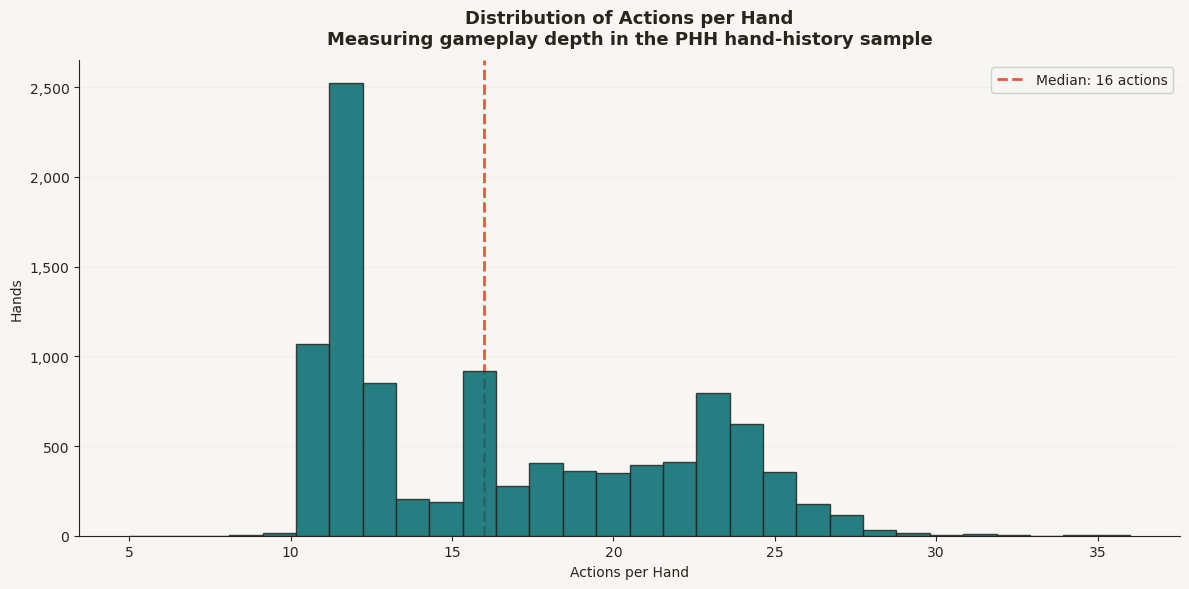

In [8]:
action_df = analysis.dropna(subset=["num_actions"]).copy()

fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(
    action_df["num_actions"],
    bins=30,
    color=TEAL,
    edgecolor=TEXT,
    alpha=0.85,
    zorder=3
)

ax.axvline(
    action_df["num_actions"].median(),
    color=RED,
    linestyle="--",
    linewidth=2,
    label=f"Median: {action_df['num_actions'].median():.0f} actions"
)

ax.set_title(
    "Distribution of Actions per Hand\n"
    "Measuring gameplay depth in the PHH hand-history sample",
    fontsize=13,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("Actions per Hand")
ax.set_ylabel("Hands")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax.grid(axis="y", alpha=0.25, color=GRID, zorder=0)
ax.legend(framealpha=0.9)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("phh_actions_per_hand_distribution.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

### Interpretation: Engagement Depth

The actions-per-hand distribution shows that most observable hands are not sprawling, one-off stories. They cluster around a fairly repeatable interaction pattern, with a median of about 16 actions and most hands sitting in a relatively tight middle range. That is useful because it gives the project a baseline for what a "normal" interaction looks like before segmenting into deeper or shallower experiences.

The right business reading is not "more actions are always better." A hand with fewer actions may represent fast, accessible product flow, while a high-action hand may represent a more involved and suspenseful experience. The value of this metric is that it turns raw logs into a pacing KPI: how often the product creates quick resolutions versus longer engagement sequences.

**Commercial read:** action depth is a practical monitoring metric for game quality, participant experience, and contest pacing. It could be tracked over time, across formats, or across player cohorts to detect whether the product is becoming too shallow, too complex, or meaningfully different by segment.


## Higher-Commitment Action Intensity

            Bet/raise share is used as a lightweight proxy for interaction intensity. It should not be interpreted as a complete poker-theory aggression metric; it simply measures how often observable actions involve higher commitment.


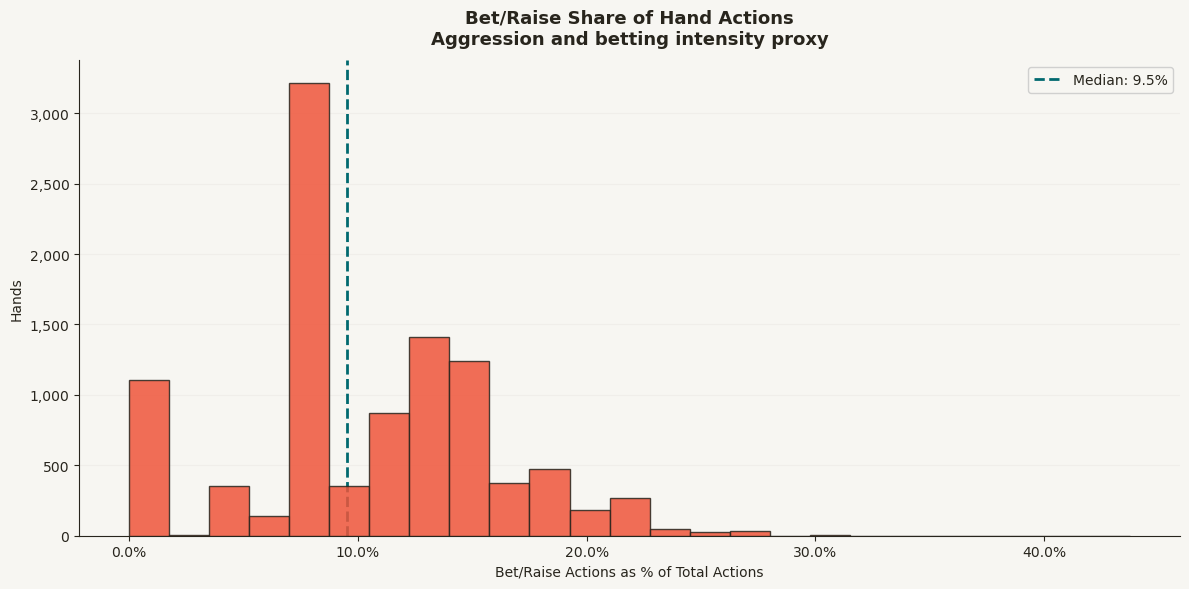

In [9]:
bet_df = analysis.dropna(subset=["bet_raise_rate"]).copy()

fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(
    bet_df["bet_raise_rate"] * 100,
    bins=25,
    color=RED,
    edgecolor=TEXT,
    alpha=0.85,
    zorder=3
)

ax.axvline(
    bet_df["bet_raise_rate"].median() * 100,
    color=TEAL,
    linestyle="--",
    linewidth=2,
    label=f"Median: {bet_df['bet_raise_rate'].median() * 100:.1f}%"
)

ax.set_title(
    "Bet/Raise Share of Hand Actions\n"
    "Aggression and betting intensity proxy",
    fontsize=13,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("Bet/Raise Actions as % of Total Actions")
ax.set_ylabel("Hands")
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax.grid(axis="y", alpha=0.25, color=GRID, zorder=0)
ax.legend(framealpha=0.9)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("phh_bet_raise_rate_distribution.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

### Interpretation: Betting Intensity

The bet/raise-rate chart shows that higher-commitment actions are a minority of total activity. The median is roughly 9.5%, and much of the distribution sits near the 8%-15% range, with a smaller tail of more action-heavy hands. That makes this a useful intensity proxy without pretending it captures complete poker strategy.

One important nuance is that this is a share metric. A medium-depth hand can show a high bet/raise rate because fewer total actions are in the denominator, while a deeper hand can contain more total bets/raises but a lower share. That distinction is useful commercially: operators may care separately about the volume of commitment actions and their density within the experience.

**Commercial read:** betting intensity can help describe product feel. Higher-intensity hands may feel more exciting or higher-stakes, while lower-intensity hands may feel more passive, accessible, or fast-moving. This is better framed as interaction intensity than as a poker-theory aggression score.


## Action-Based Experience Segments

            Rather than treating every hand as interchangeable inventory, the notebook groups hands into low-, medium-, and high-action segments. This converts raw hand histories into a product analytics segmentation.


In [10]:
seg_df = analysis.dropna(subset=["num_actions", "bet_raise_rate"]).copy()

seg_df["action_segment"] = pd.qcut(
    seg_df["num_actions"],
    q=3,
    labels=["Low-Action Hands", "Medium-Action Hands", "High-Action Hands"]
)

segment_summary = (
    seg_df
    .groupby("action_segment", as_index=False, observed=True)
    .agg(
        hands=("file", "count"),
        avg_actions=("num_actions", "mean"),
        avg_bets_raises=("num_bets_raises", "mean"),
        avg_bet_raise_rate=("bet_raise_rate", "mean"),
        showdown_like_rate=("showdown_like_hand", "mean"),
        avg_players=("num_players", "mean")
    )
)

segment_summary["hand_share"] = segment_summary["hands"] / segment_summary["hands"].sum()

segment_summary

,action_segment,hands,avg_actions,avg_bets_raises,avg_bet_raise_rate,showdown_like_rate,avg_players,hand_share
0,Low-Action Hands,3606,11.693012,0.707432,0.059075,0.000000,5.991681,0.357454
1,Medium-Action Hands,3202,15.691443,2.182074,0.139997,0.003123,5.986883,0.317407
2,High-Action Hands,3280,23.153049,2.806402,0.121793,0.519512,5.984451,0.325139


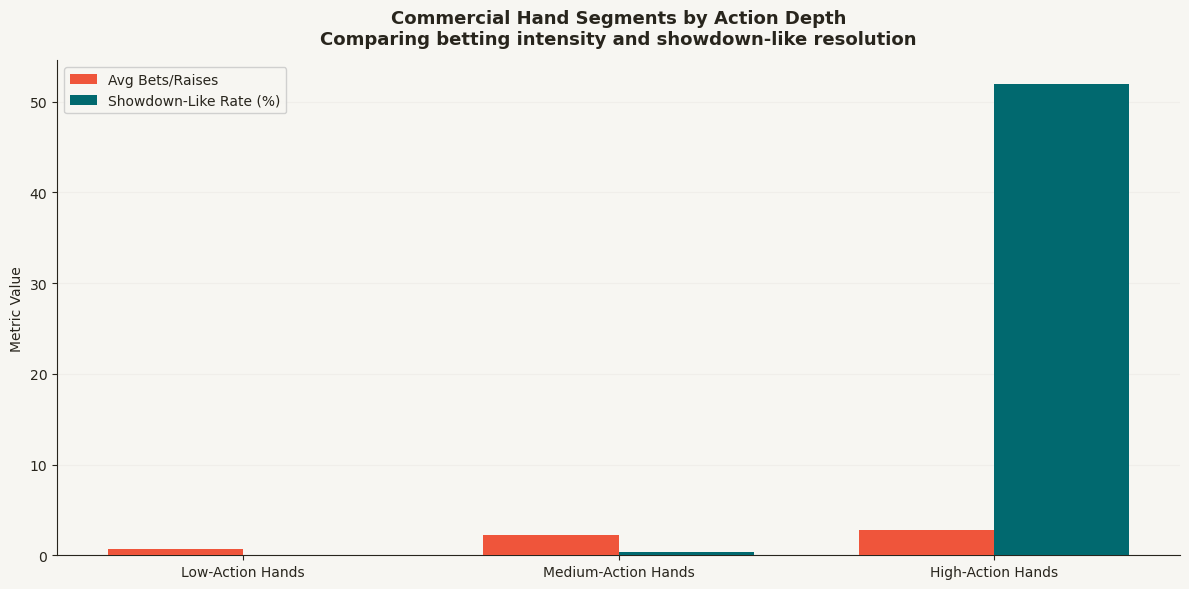

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(segment_summary))
width = 0.36

ax.bar(
    x - width / 2,
    segment_summary["avg_bets_raises"],
    width,
    label="Avg Bets/Raises",
    color=RED,
    zorder=3
)

ax.bar(
    x + width / 2,
    segment_summary["showdown_like_rate"] * 100,
    width,
    label="Showdown-Like Rate (%)",
    color=TEAL,
    zorder=3
)

ax.set_xticks(x)
ax.set_xticklabels(segment_summary["action_segment"])

ax.set_title(
    "Commercial Hand Segments by Action Depth\n"
    "Comparing betting intensity and showdown-like resolution",
    fontsize=13,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("")
ax.set_ylabel("Metric Value")
ax.grid(axis="y", alpha=0.25, color=GRID, zorder=0)
ax.legend(framealpha=0.9)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("phh_hand_segments_by_action_depth.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

In [12]:
segment_display = segment_summary.copy()

segment_display["hand_share"] = segment_display["hand_share"].map(lambda x: f"{x:.1%}")
segment_display["avg_actions"] = segment_display["avg_actions"].round(2)
segment_display["avg_bets_raises"] = segment_display["avg_bets_raises"].round(2)
segment_display["avg_bet_raise_rate"] = segment_display["avg_bet_raise_rate"].map(lambda x: f"{x:.1%}")
segment_display["showdown_like_rate"] = segment_display["showdown_like_rate"].map(lambda x: f"{x:.1%}")
segment_display["avg_players"] = segment_display["avg_players"].round(2)

segment_display.rename(columns={
    "action_segment": "Hand Segment",
    "hands": "Hands",
    "hand_share": "Hand Share",
    "avg_actions": "Avg Actions",
    "avg_bets_raises": "Avg Bets/Raises",
    "avg_bet_raise_rate": "Avg Bet/Raise Rate",
    "showdown_like_rate": "Showdown-Like Rate",
    "avg_players": "Avg Players"
})

,Hand Segment,Hands,Avg Actions,Avg Bets/Raises,Avg Bet/Raise Rate,Showdown-Like Rate,Avg Players,Hand Share
0,Low-Action Hands,3606,11.69,0.71,5.9%,0.0%,5.99,35.7%
1,Medium-Action Hands,3202,15.69,2.18,14.0%,0.3%,5.99,31.7%
2,High-Action Hands,3280,23.15,2.81,12.2%,52.0%,5.98,32.5%


### Interpretation: Experience Segments

The action-segment table is one of the strongest portfolio pieces in the notebook because it converts messy event logs into a clean product segmentation. The three groups are similar in size, but they represent very different experiences: low-action hands average about 11.7 actions, medium-action hands about 15.7, and high-action hands about 23.2.

The most important pattern is that showdown-like resolution is almost absent in low- and medium-action hands, but appears in roughly half of high-action hands. That means the high-action segment is not just "more clicks." It is a different lifecycle pattern, where hands are more likely to continue into deeper public resolution states.

The medium-action segment also matters because it has the highest bet/raise share, even though high-action hands have more bets/raises in absolute terms. That is a good example of why the notebook uses multiple KPIs instead of one master score.

**Commercial read:** these segments could become a lightweight product dashboard. A platform could monitor the mix of low-, medium-, and high-engagement experiences by format, stake level, time period, acquisition cohort, or player tenure.


## Street-Level Engagement Funnel

The earlier action-depth metric counts observable activity across the whole hand. A more product-oriented view asks where participants disengage during the interaction lifecycle.

This section splits player decisions into preflop, flop, turn, and river using public board-deal events as street boundaries. Dealer events are not counted as participant decisions, so this is closer to user agency than the raw action count.

In [13]:
street_survival_summary = pd.DataFrame([
    {"street": "Preflop", "hands": len(analysis), "hand_share": 1.0},
    {"street": "Flop", "hands": int(analysis["reached_flop"].sum()), "hand_share": analysis["reached_flop"].mean()},
    {"street": "Turn", "hands": int(analysis["reached_turn"].sum()), "hand_share": analysis["reached_turn"].mean()},
    {"street": "River", "hands": int(analysis["reached_river"].sum()), "hand_share": analysis["reached_river"].mean()},
])

street_intensity_rows = []
for street in ["preflop", "flop", "turn", "river"]:
    reached_col = {
        "preflop": None,
        "flop": "reached_flop",
        "turn": "reached_turn",
        "river": "reached_river",
    }[street]
    mask = analysis[reached_col].eq(True) if reached_col else analysis["num_player_decisions"].notna()
    street_intensity_rows.append({
        "street": street.capitalize(),
        "hands_reached": int(mask.sum()),
        "avg_decisions": analysis.loc[mask, f"{street}_decisions"].mean(),
        "avg_bet_raise_rate": analysis.loc[mask, f"{street}_bet_raise_rate"].mean(),
        "avg_fold_rate": analysis.loc[mask, f"{street}_fold_rate"].mean(),
    })

street_intensity_summary = pd.DataFrame(street_intensity_rows)

display(street_survival_summary)
display(street_intensity_summary)


,street,hands,hand_share
0,Preflop,10088,1.000000
1,Flop,5368,0.532117
2,Turn,3880,0.384615
3,River,2771,0.274683


,street,hands_reached,avg_decisions,avg_bet_raise_rate,avg_fold_rate
0,Preflop,10088,6.181602,0.168194,0.722513
1,Flop,5368,2.637295,0.227830,0.109253
2,Turn,3880,2.384278,0.233079,0.123709
3,River,2771,2.321545,0.277008,0.169446


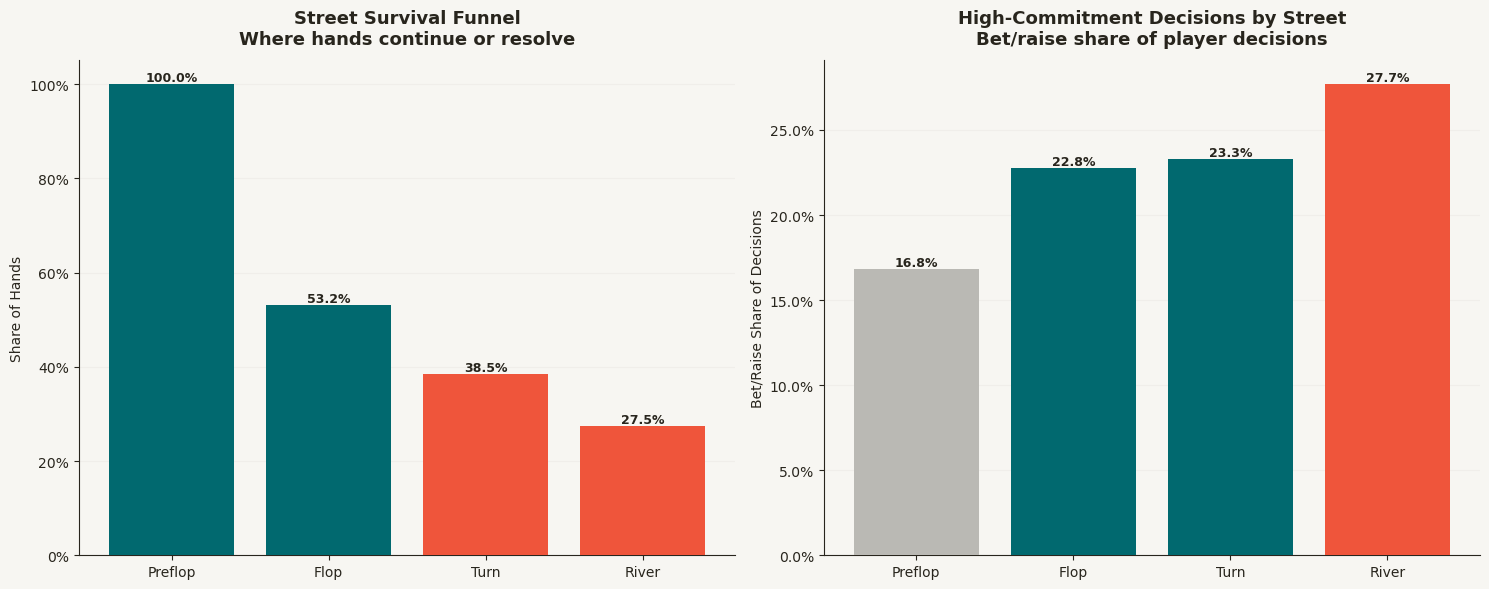

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
bars = ax.bar(
    street_survival_summary["street"],
    street_survival_summary["hand_share"] * 100,
    color=[TEAL, TEAL, RED, RED],
    zorder=3,
)
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )
ax.set_title("Street Survival Funnel\nWhere hands continue or resolve", fontsize=13, fontweight="bold", pad=12)
ax.set_ylabel("Share of Hands")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(axis="y", alpha=0.25, color=GRID, zorder=0)
ax.spines[["top", "right"]].set_visible(False)

ax = axes[1]
bars = ax.bar(
    street_intensity_summary["street"],
    street_intensity_summary["avg_bet_raise_rate"] * 100,
    color=[GRAY, TEAL, TEAL, RED],
    zorder=3,
)
for bar in bars:
    height = bar.get_height()
    if pd.notna(height):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
        )
ax.set_title("High-Commitment Decisions by Street\nBet/raise share of player decisions", fontsize=13, fontweight="bold", pad=12)
ax.set_ylabel("Bet/Raise Share of Decisions")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(axis="y", alpha=0.25, color=GRID, zorder=0)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("phh_street_level_engagement.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()


### Interpretation: Street-Level Engagement

The street funnel turns action logs into a retention-style product metric. Instead of only saying that some hands have more actions, it shows how many interactions survive into later public stages. That is a more commercially useful framing because it identifies where the product experience resolves quickly and where it becomes deeper, more suspenseful, and more economically meaningful.

The street-level bet/raise rates should be read as descriptive behavior, not poker advice. They help separate early commitment behavior from later-street commitment behavior, which is exactly the kind of segmentation a gaming analytics team would use when monitoring engagement quality across formats, cohorts, or product changes.

## Contest Lifecycle Depth

            Action count measures how many observable events occurred, but a lifecycle view is easier for non-poker stakeholders to understand. This section groups hands by how far they progressed through the public contest sequence before resolving.

            The business question is: **what share of interactions end quickly versus becoming deeper, more visible experiences?**


In [15]:
def classify_lifecycle_depth(path):
    path = Path(path)
    with open(path, "rb") as f:
        hh = HandHistory.load(f)

    actions = [str(a).lower().strip() for a in getattr(hh, "actions", [])]
    codes = [action_code(a) for a in actions]

    board_deals = sum(code == "db" for code in codes)
    if board_deals == 0:
        lifecycle_stage = "No Board Reveal"
    elif board_deals == 1:
        lifecycle_stage = "First Board Reveal"
    elif board_deals == 2:
        lifecycle_stage = "Second Board Reveal"
    else:
        lifecycle_stage = "Final Board Reveal"

    first_board_index = next((i for i, code in enumerate(codes) if code == "db"), None)
    pre_board_actions = sum(
        code in {"f", "cc", "cbr"}
        for i, code in enumerate(codes)
        if first_board_index is None or i < first_board_index
    )
    post_board_actions = sum(
        code in {"f", "cc", "cbr"}
        for i, code in enumerate(codes)
        if first_board_index is not None and i > first_board_index
    )

    last_non_deal_code = None
    for code in reversed(codes):
        if code and code not in {"dh", "db", "df", "dt", "dr"}:
            last_non_deal_code = code
            break

    return {
        "file": str(path),
        "source_folder": source_folder(path),
        "lifecycle_stage": lifecycle_stage,
        "board_deals": board_deals,
        "pre_board_actions": pre_board_actions,
        "post_board_actions": post_board_actions,
        "terminal_code": last_non_deal_code,
    }

lifecycle_df = pd.DataFrame(
    [classify_lifecycle_depth(path) for path in tqdm(phh_files, desc="Classifying lifecycle depth")]
)

lifecycle_analysis = analysis.merge(lifecycle_df, on="file", how="left")

lifecycle_order = [
    "No Board Reveal",
    "First Board Reveal",
    "Second Board Reveal",
    "Final Board Reveal",
]

lifecycle_summary = (
    lifecycle_analysis
    .groupby("lifecycle_stage", as_index=False)
    .agg(
        hands=("file", "count"),
        avg_actions=("num_actions", "mean"),
        avg_pre_board_actions=("pre_board_actions", "mean"),
        avg_post_board_actions=("post_board_actions", "mean"),
        avg_bets_raises=("num_bets_raises", "mean"),
        showdown_like_rate=("showdown_like_hand", "mean"),
    )
)

lifecycle_summary["lifecycle_stage"] = pd.Categorical(
    lifecycle_summary["lifecycle_stage"],
    categories=lifecycle_order,
    ordered=True,
)
lifecycle_summary = lifecycle_summary.sort_values("lifecycle_stage")
lifecycle_summary["hand_share"] = lifecycle_summary["hands"] / lifecycle_summary["hands"].sum()

lifecycle_summary


Classifying lifecycle depth:   0%|          | 0/10088 [00:00<?, ?it/s]

Classifying lifecycle depth:   1%|          | 110/10088 [00:00<00:09, 1090.45it/s]

Classifying lifecycle depth:   2%|▏         | 220/10088 [00:00<00:10, 965.80it/s] 

Classifying lifecycle depth:   3%|▎         | 353/10088 [00:00<00:08, 1116.98it/s]

Classifying lifecycle depth:   5%|▍         | 467/10088 [00:00<00:08, 1088.73it/s]

...

Classifying lifecycle depth:  95%|█████████▍| 9583/10088 [00:06<00:00, 2325.80it/s]

Classifying lifecycle depth:  98%|█████████▊| 9836/10088 [00:06<00:00, 2384.76it/s]

Classifying lifecycle depth: 100%|█████████▉| 10077/10088 [00:06<00:00, 2376.06it/s]

Classifying lifecycle depth: 100%|██████████| 10088/10088 [00:06<00:00, 1598.61it/s]

,lifecycle_stage,hands,avg_actions,avg_pre_board_actions,avg_post_board_actions,avg_bets_raises,showdown_like_rate,hand_share
2,No Board Reveal,4720,12.139619,6.096610,0.000000,1.042797,0.004025,0.467883
1,First Board Reveal,1488,16.302419,6.265457,3.039651,2.246640,0.000000,0.147502
3,Second Board Reveal,1109,19.438233,6.208296,5.232642,2.646528,0.000000,0.109933
0,Final Board Reveal,2771,23.542764,6.270660,7.042584,2.722122,0.611693,0.274683


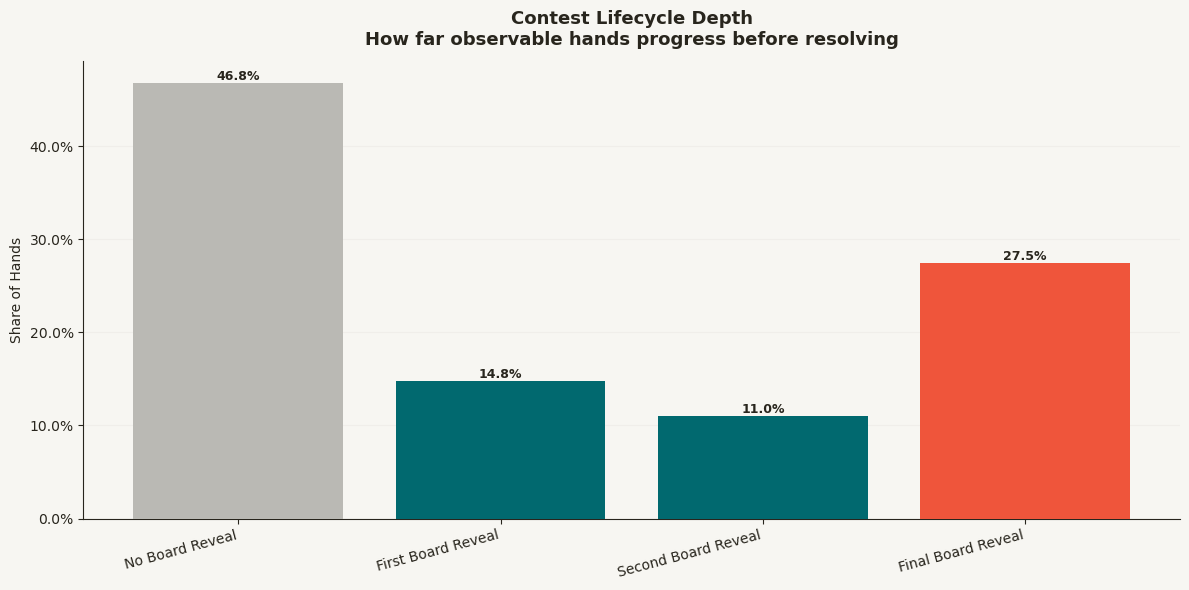

In [16]:
fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(
    lifecycle_summary["lifecycle_stage"].astype(str),
    lifecycle_summary["hand_share"] * 100,
    color=[GRAY, TEAL, TEAL, RED],
    zorder=3,
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )

ax.set_title(
    "Contest Lifecycle Depth\n"
    "How far observable hands progress before resolving",
    fontsize=13,
    fontweight="bold",
    pad=12,
)

ax.set_xlabel("")
ax.set_ylabel("Share of Hands")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(axis="y", alpha=0.25, color=GRID, zorder=0)
ax.spines[["top", "right"]].set_visible(False)

plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("phh_contest_lifecycle_depth.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()


### Interpretation: Contest Lifecycle Depth

The lifecycle chart makes the analysis much easier for non-poker readers to understand. Nearly half of hands resolve before any board reveal, while about 27.5% reach the final board reveal. The remaining hands fall between those endpoints, reaching the first or second public reveal before resolving.

This is more intuitive than only counting actions because it describes how far the interaction progressed through the product experience. The summary table shows that pre-board activity is fairly stable across stages, while post-board activity is what separates shallow hands from deeper hands. In other words, the funnel is not just about volume; it captures whether the experience continues into later decision points.

**Commercial read:** lifecycle depth is a contest funnel. It tells an operator whether the product is mostly producing quick resolutions, deeper suspense moments, or a balanced mix. That matters for engagement design, player experience, and format comparison.


## Card Visibility and Data Quality

            This is the most important caveat in the project. The PHH logs do not consistently expose private cards or winner-side cards. That limits strategy and hand-strength analysis, but it does not eliminate the value of action-based behavioral analytics.


In [17]:
card_rows = [parse_card_visibility(path) for path in tqdm(phh_files, desc="Scanning card visibility")]
card_df = pd.DataFrame(card_rows)

card_df.head()


Scanning card visibility:   0%|          | 0/10088 [00:00<?, ?it/s]

Scanning card visibility:   2%|▏         | 229/10088 [00:00<00:04, 2283.51it/s]

Scanning card visibility:   5%|▍         | 458/10088 [00:00<00:04, 2146.81it/s]

Scanning card visibility:   7%|▋         | 689/10088 [00:00<00:04, 2215.72it/s]

Scanning card visibility:   9%|▉         | 917/10088 [00:00<00:04, 2238.45it/s]

...

Scanning card visibility:  96%|█████████▌| 9649/10088 [00:04<00:00, 2009.15it/s]

Scanning card visibility:  98%|█████████▊| 9875/10088 [00:04<00:00, 2079.69it/s]

Scanning card visibility: 100%|█████████▉| 10086/10088 [00:04<00:00, 2026.66it/s]

Scanning card visibility: 100%|██████████| 10088/10088 [00:04<00:00, 2214.68it/s]

,file,filename,parse_success,variant,year,num_players,num_actions,source_folder,source_type_detailed,is_wsop,...,event_id,table_id,has_actions,known_card_count,unknown_card_token_count,has_known_cards,has_unknown_cards,show_muck_actions,known_show_muck_actions,known_cards
0,C:\Users\J1999\Downloads\poker-hand-histories\...,alice-carol-wikipedia.phh,True,FB,NaN,4,36,root_examples,Reference examples,False,...,None,None,True,0,64,False,True,10,0,None
1,C:\Users\J1999\Downloads\poker-hand-histories\...,antonius-blom-2009.phh,True,PO,2009.0,2,16,root_examples,Reference examples,False,...,None,None,True,2,0,True,False,2,0,"[5h, 9c]"
2,C:\Users\J1999\Downloads\poker-hand-histories\...,arieh-yockey-2019.phh,True,F2L3D,2019.0,4,26,root_examples,Reference examples,False,...,None,None,True,4,20,True,True,8,2,"[qh, 4d, 6s, 7c]"
3,C:\Users\J1999\Downloads\poker-hand-histories\...,dwan-ivey-2009.phh,True,NT,2009.0,3,18,root_examples,Reference examples,False,...,None,None,True,2,4,True,True,2,0,"[4h, jh]"
4,C:\Users\J1999\Downloads\poker-hand-histories\...,phua-xuan-2019.phh,True,NS,2019.0,6,20,root_examples,Reference examples,False,...,None,None,True,2,0,True,False,2,0,"[jh, ts]"


In [18]:
card_summary = pd.DataFrame([{
    "hands": len(card_df),
    "parse_success_rate": card_df["parse_success"].mean(),
    "hands_with_known_cards": card_df["has_known_cards"].mean(),
    "hands_with_unknown_cards": card_df["has_unknown_cards"].mean(),
    "avg_known_card_count": card_df["known_card_count"].mean(),
    "median_known_card_count": card_df["known_card_count"].median(),
    "avg_show_muck_actions": card_df["show_muck_actions"].mean(),
    "avg_known_show_muck_actions": card_df["known_show_muck_actions"].mean(),
}])

card_summary.T

,0
hands,10088.000000
parse_success_rate,1.000000
hands_with_known_cards,0.387589
hands_with_unknown_cards,0.001883
avg_known_card_count,0.675555
median_known_card_count,0.000000
avg_show_muck_actions,0.349921
avg_known_show_muck_actions,0.001487


In [19]:
analysis_cards = analysis.merge(
    card_df[[
        "file",
        "known_card_count",
        "unknown_card_token_count",
        "has_known_cards",
        "has_unknown_cards",
        "show_muck_actions",
        "known_show_muck_actions",
        "known_cards"
    ]],
    on="file",
    how="left"
)

analysis_cards.head()

,file,filename,parse_success,parse_error,variant,currency,year,city,country,players,...,decisions_per_player,bets_raises_per_player,showdown_like_hand,known_card_count,unknown_card_token_count,has_known_cards,has_unknown_cards,show_muck_actions,known_show_muck_actions,known_cards
0,C:\Users\J1999\Downloads\poker-hand-histories\...,alice-carol-wikipedia.phh,True,None,FB,None,NaN,None,None,"[Bob, Carol, Ted, Alice]",...,4.000000,1.000000,True,0,64,False,True,10,0,None
1,C:\Users\J1999\Downloads\poker-hand-histories\...,antonius-blom-2009.phh,True,None,PO,USD,2009.0,None,None,"[Patrik Antonius, Victor Blom]",...,4.500000,3.500000,True,2,0,True,False,2,0,"[5h, 9c]"
2,C:\Users\J1999\Downloads\poker-hand-histories\...,arieh-yockey-2019.phh,True,None,F2L3D,None,2019.0,Las Vegas,United States of America,"[Bryce Yockey, Phil Hui, John Esposito, Josh A...",...,2.750000,1.250000,True,4,20,True,True,8,2,"[qh, 4d, 6s, 7c]"
3,C:\Users\J1999\Downloads\poker-hand-histories\...,dwan-ivey-2009.phh,True,None,NT,USD,2009.0,None,None,"[Phil Ivey, Patrik Antonius, Tom Dwan]",...,3.333333,2.000000,True,2,4,True,True,2,0,"[4h, jh]"
4,C:\Users\J1999\Downloads\poker-hand-histories\...,phua-xuan-2019.phh,True,None,NS,GBP,2019.0,London,United Kingdom,"[Mikita Badziakouski, Liu Ming Zhong, Tan Xuan...",...,1.500000,0.333333,True,2,0,True,False,2,0,"[jh, ts]"


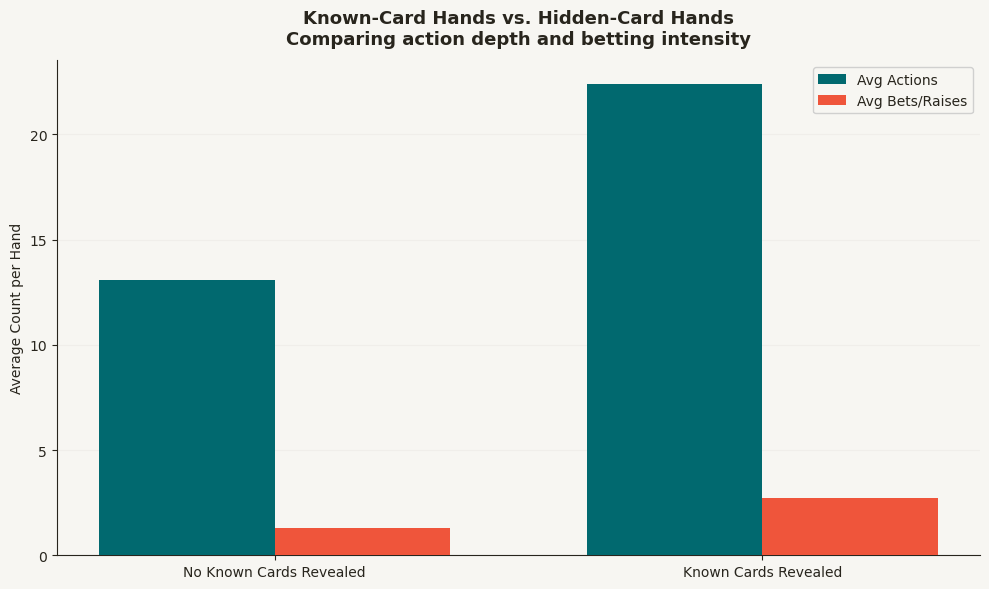

,has_known_cards,hands,avg_actions,avg_bets_raises,avg_bet_raise_rate,showdown_like_rate,label
0,False,6178,13.080123,1.318388,0.094788,0.000162,No Known Cards Revealed
1,True,3910,22.389258,2.710486,0.121529,0.438107,Known Cards Revealed


In [20]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plot_df = analysis_cards.dropna(subset=["num_actions", "has_known_cards"]).copy()

known_summary = (
    plot_df
    .groupby("has_known_cards", as_index=False)
    .agg(
        hands=("file", "count"),
        avg_actions=("num_actions", "mean"),
        avg_bets_raises=("num_bets_raises", "mean"),
        avg_bet_raise_rate=("bet_raise_rate", "mean"),
        showdown_like_rate=("showdown_like_hand", "mean")
    )
)

known_summary["label"] = np.where(
    known_summary["has_known_cards"],
    "Known Cards Revealed",
    "No Known Cards Revealed"
)

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(known_summary))
width = 0.36

ax.bar(
    x - width / 2,
    known_summary["avg_actions"],
    width,
    label="Avg Actions",
    color=TEAL,
    zorder=3
)

ax.bar(
    x + width / 2,
    known_summary["avg_bets_raises"],
    width,
    label="Avg Bets/Raises",
    color=RED,
    zorder=3
)

ax.set_xticks(x)
ax.set_xticklabels(known_summary["label"])

ax.set_title(
    "Known-Card Hands vs. Hidden-Card Hands\n"
    "Comparing action depth and betting intensity",
    fontsize=13,
    fontweight="bold",
    pad=12
)

ax.set_ylabel("Average Count per Hand")
ax.grid(axis="y", alpha=0.25, color=GRID, zorder=0)
ax.legend(framealpha=0.9)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("phh_known_cards_vs_hidden_cards.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

known_summary

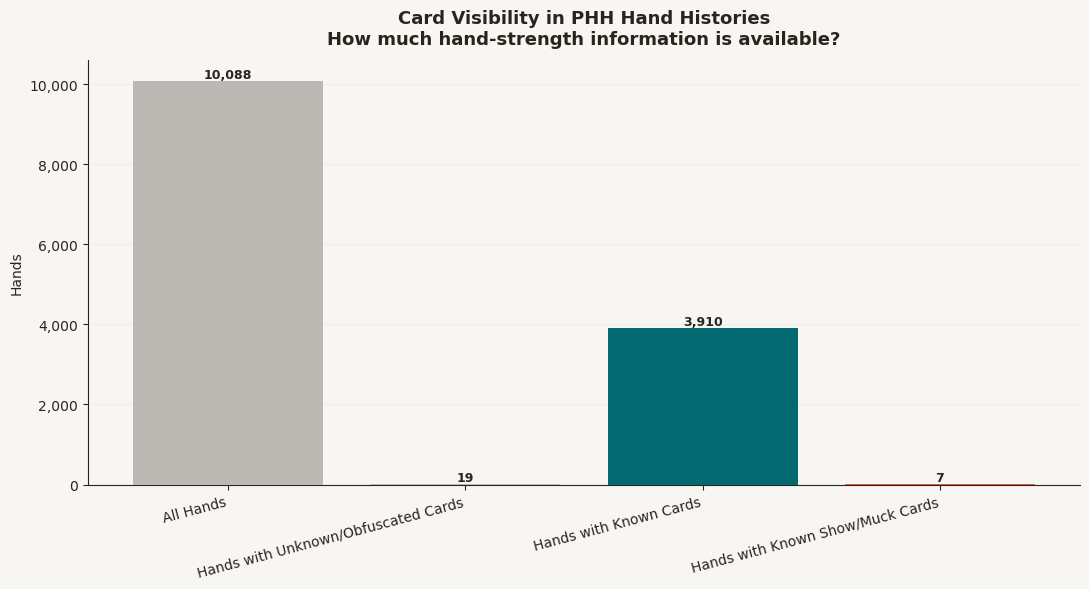

,category,hands
0,All Hands,10088
1,Hands with Unknown/Obfuscated Cards,19
2,Hands with Known Cards,3910
3,Hands with Known Show/Muck Cards,7


In [21]:
visibility_counts = pd.DataFrame({
    "category": [
        "All Hands",
        "Hands with Unknown/Obfuscated Cards",
        "Hands with Known Cards",
        "Hands with Known Show/Muck Cards"
    ],
    "hands": [
        len(card_df),
        int(card_df["has_unknown_cards"].sum()),
        int(card_df["has_known_cards"].sum()),
        int((card_df["known_show_muck_actions"].fillna(0) > 0).sum())
    ]
})

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.bar(
    visibility_counts["category"],
    visibility_counts["hands"],
    color=[GRAY, GRAY, TEAL, RED],
    zorder=3
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

ax.set_title(
    "Card Visibility in PHH Hand Histories\n"
    "How much hand-strength information is available?",
    fontsize=13,
    fontweight="bold",
    pad=12
)

ax.set_ylabel("Hands")
ax.set_xticks(range(len(visibility_counts)))
ax.set_xticklabels(visibility_counts["category"], rotation=15, ha="right")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax.grid(axis="y", alpha=0.25, color=GRID, zorder=0)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("phh_card_visibility_funnel.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

visibility_counts


### Interpretation: Visibility Constraints

The card-visibility funnel confirms that this dataset should be treated as imperfect observational event data. Known cards appear somewhere in 3,910 of 10,088 hands, but the median known-card count is still zero. That means known-card availability is uneven, and most hands do not expose enough card information to support full hand-strength analysis.

The chart also shows why the notebook needs a separate validation section. A broad card scan can find known cards in some show/muck-like contexts, but the stricter resolution test later shows that terminal show/muck activity does not reliably provide full card text. That distinction is important: visible cards exist, but they are not complete enough to support strategy or decision-quality claims.

**Commercial read:** visibility is itself a data-quality KPI. For this public PHH corpus, the reliable analytic surface is observable action behavior, lifecycle depth, and outcome dynamics. An operator with complete internal logs could extend the same workflow to richer card, account, and retention features.


## Resolution Path Breakdown

            The terminal action gives a simple view of how hands resolve. This is not a card-visibility measure; it is a resolution-path measure.


In [22]:
resolution_map = {
    "f": "Resolved Before Show/Muck",
    "sm": "Show/Muck-Like Resolution",
    "sd": "Showdown-Like Resolution",
}

resolution_summary = (
    lifecycle_analysis
    .assign(resolution_path=lambda df: df["terminal_code"].map(resolution_map).fillna("Other / Unknown"))
    .groupby("resolution_path", as_index=False)
    .agg(
        hands=("file", "count"),
        avg_actions=("num_actions", "mean"),
        avg_bets_raises=("num_bets_raises", "mean"),
        avg_lifecycle_board_deals=("board_deals", "mean"),
    )
    .sort_values("hands", ascending=False)
)

resolution_summary["hand_share"] = resolution_summary["hands"] / resolution_summary["hands"].sum()

resolution_summary


,resolution_path,hands,avg_actions,avg_bets_raises,avg_lifecycle_board_deals,hand_share
0,Resolved Before Show/Muck,8374,15.152615,1.720325,0.828039,0.830095
1,Show/Muck-Like Resolution,1714,24.190782,2.530338,2.966744,0.169905


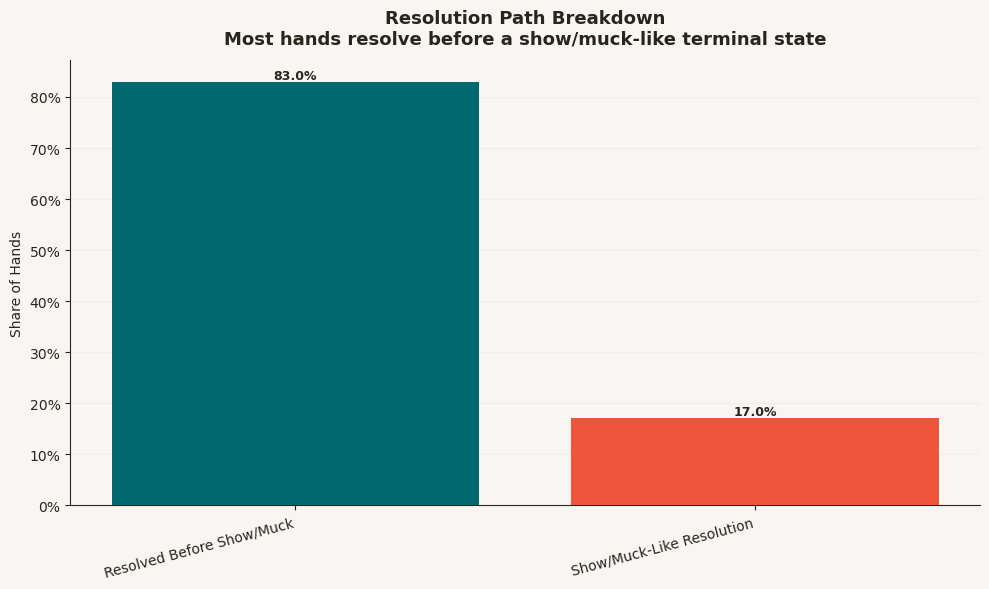

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    resolution_summary["resolution_path"],
    resolution_summary["hand_share"] * 100,
    color=[TEAL, RED, GRAY][:len(resolution_summary)],
    zorder=3,
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )

ax.set_title(
    "Resolution Path Breakdown\n"
    "Most hands resolve before a show/muck-like terminal state",
    fontsize=13,
    fontweight="bold",
    pad=12,
)

ax.set_xlabel("")
ax.set_ylabel("Share of Hands")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(axis="y", alpha=0.25, color=GRID, zorder=0)
ax.spines[["top", "right"]].set_visible(False)

plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("phh_resolution_path_breakdown.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()


### Interpretation: Resolution Paths

The resolution-path chart shows a clean split: about 83% of hands resolve before show/muck-like activity, while about 17% reach a show/muck-like terminal state. The show/muck-like hands are much deeper on average, with roughly 24 actions versus about 15 actions for hands that resolve earlier.

This supports the lifecycle story. The later a hand resolves, the more observable interaction it tends to create. Show/muck-like hands also average almost three board-deal stages, which means they usually progress much farther through the public contest lifecycle.

The caveat is essential: show/muck-like resolution is not the same as full card disclosure. It is a resolution-path measure, not a hand-strength measure.

**Commercial read:** resolution path is useful for measuring experience clarity and contest pacing. It helps identify which interactions end quickly and which create more visible, suspenseful terminal moments.


## Contest Outcome Intensity

            The next section shifts away from card strength and toward parsed economic outcomes. Winner-side card visibility is too limited for strategy conclusions, but stack and outcome data can still help describe which hands create larger observable value swings.


### Outcome Parser

Winner-side outcome extraction uses the reusable helper layer. It identifies positive stack changes where available, checks winner-card visibility, and carries forward the same action metrics used earlier in the notebook.


In [24]:
winner_rows = [parse_winner_outcome(path) for path in tqdm(phh_files, desc="Parsing winner-side hand data")]

winner_df = pd.DataFrame(winner_rows)

print(winner_df.shape)
display(winner_df.head())


Parsing winner-side hand data:   0%|          | 0/10088 [00:00<?, ?it/s]

Parsing winner-side hand data:   2%|▏         | 174/10088 [00:00<00:05, 1733.03it/s]

Parsing winner-side hand data:   4%|▎         | 360/10088 [00:00<00:05, 1805.47it/s]

Parsing winner-side hand data:   5%|▌         | 541/10088 [00:00<00:05, 1699.14it/s]

Parsing winner-side hand data:   7%|▋         | 712/10088 [00:00<00:05, 1677.65it/s]

...

Parsing winner-side hand data:  97%|█████████▋| 9808/10088 [00:05<00:00, 1809.15it/s]

Parsing winner-side hand data:  99%|█████████▉| 9990/10088 [00:05<00:00, 1794.01it/s]

Parsing winner-side hand data: 100%|██████████| 10088/10088 [00:05<00:00, 1684.78it/s]

(10088, 73)


,file,filename,parse_success,variant,currency,year,players,num_players,starting_stacks,finishing_stacks,...,river_decisions,river_bets_raises,river_folds,river_calls_checks,river_bet_raise_rate,river_fold_rate,reached_flop,reached_turn,reached_river,showdown_like_hand
0,C:\Users\J1999\Downloads\poker-hand-histories\...,alice-carol-wikipedia.phh,True,FB,None,NaN,"[Bob, Carol, Ted, Alice]",4,"[200, 200, 200, 200]",None,...,0,0,0,0,NaN,NaN,False,False,False,True
1,C:\Users\J1999\Downloads\poker-hand-histories\...,antonius-blom-2009.phh,True,PO,USD,2009.0,"[Patrik Antonius, Victor Blom]",2,"[1259450.25, 678473.5]",None,...,0,0,0,0,NaN,NaN,True,True,True,True
2,C:\Users\J1999\Downloads\poker-hand-histories\...,arieh-yockey-2019.phh,True,F2L3D,None,2019.0,"[Bryce Yockey, Phil Hui, John Esposito, Josh A...",4,"[1180000, 4340000, 5910000, 10765000]",None,...,0,0,0,0,NaN,NaN,False,False,False,True
3,C:\Users\J1999\Downloads\poker-hand-histories\...,dwan-ivey-2009.phh,True,NT,USD,2009.0,"[Phil Ivey, Patrik Antonius, Tom Dwan]",3,"[1125600, 2000000, 553500]",None,...,0,0,0,0,NaN,NaN,True,True,True,True
4,C:\Users\J1999\Downloads\poker-hand-histories\...,phua-xuan-2019.phh,True,NS,GBP,2019.0,"[Mikita Badziakouski, Liu Ming Zhong, Tan Xuan...",6,"[495000, 232000, 362000, 403000, 301000, 204000]",None,...,0,0,0,0,NaN,NaN,True,True,True,True


In [25]:
print("Parse success:")
display(winner_df["parse_success"].value_counts(dropna=False))

print("\nNumber of winners per hand:")
display(winner_df["num_winners"].value_counts(dropna=False).sort_index())

print("\nWinner known-card visibility:")
display(winner_df["winner_has_known_cards"].value_counts(normalize=True, dropna=False))

print("\nHand known-card visibility:")
display(winner_df["hand_has_known_cards"].value_counts(normalize=True, dropna=False))

print("\nCore winner-side metrics:")
display(winner_df[[
    "num_actions",
    "num_bets_raises",
    "bet_raise_rate",
    "num_showdown_like",
    "winner_known_card_count",
    "hand_known_card_count"
]].describe())

Parse success:


parse_success
True    10088
Name: count, dtype: int64


Number of winners per hand:


num_winners
0      41
1    9991
2      56
Name: count, dtype: int64


Winner known-card visibility:


winner_has_known_cards
False    0.997224
True     0.002776
Name: proportion, dtype: float64


Hand known-card visibility:


hand_has_known_cards
False    0.612411
True     0.387589
Name: proportion, dtype: float64


Core winner-side metrics:


,num_actions,num_bets_raises,bet_raise_rate,num_showdown_like,winner_known_card_count,hand_known_card_count
count,10088.000000,10088.000000,10088.000000,10088.000000,10088.000000,10088.000000
mean,16.688243,1.857950,0.105152,0.349921,0.008921,0.675555
std,5.057247,1.199759,0.055205,0.793474,0.199433,0.927804
min,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,12.000000,1.000000,0.083333,0.000000,0.000000,0.000000
50%,16.000000,2.000000,0.095238,0.000000,0.000000,0.000000
75%,22.000000,3.000000,0.142857,0.000000,0.000000,2.000000
max,36.000000,7.000000,0.437500,10.000000,8.000000,10.000000


In [26]:
winner_value_df = winner_df[winner_df["parse_success"].eq(True)].copy()

def max_positive_net(net_changes):
    if isinstance(net_changes, list) and len(net_changes) > 0:
        vals = [x for x in net_changes if isinstance(x, (int, float))]
        positives = [x for x in vals if x > 0]
        return max(positives) if positives else np.nan
    return np.nan

def total_positive_net(net_changes):
    if isinstance(net_changes, list) and len(net_changes) > 0:
        vals = [x for x in net_changes if isinstance(x, (int, float))]
        positives = [x for x in vals if x > 0]
        return sum(positives) if positives else np.nan
    return np.nan

winner_value_df["max_winner_net"] = winner_value_df["net_changes"].apply(max_positive_net)
winner_value_df["total_positive_net"] = winner_value_df["net_changes"].apply(total_positive_net)

winner_value_df["has_showdown"] = winner_value_df["showdown_like_hand"]
winner_value_df["actions_per_player"] = winner_value_df["num_actions"] / winner_value_df["num_players"]

winner_value_df[[
    "num_actions",
    "num_bets_raises",
    "bet_raise_rate",
    "showdown_like_hand",
    "max_winner_net",
    "total_positive_net"
]].describe()

,num_actions,num_bets_raises,bet_raise_rate,max_winner_net,total_positive_net
count,10088.000000,10088.000000,10088.000000,1.004700e+04,1.004700e+04
mean,16.688243,1.857950,0.105152,8.350668e+03,8.394548e+03
std,5.057247,1.199759,0.055205,1.143900e+05,1.144417e+05
min,5.000000,0.000000,0.000000,2.500000e+01,5.000000e+01
25%,12.000000,1.000000,0.083333,1.500000e+02,1.500000e+02
50%,16.000000,2.000000,0.095238,2.750000e+02,2.750000e+02
75%,22.000000,3.000000,0.142857,6.000000e+02,6.000000e+02
max,36.000000,7.000000,0.437500,3.750000e+06,3.750000e+06


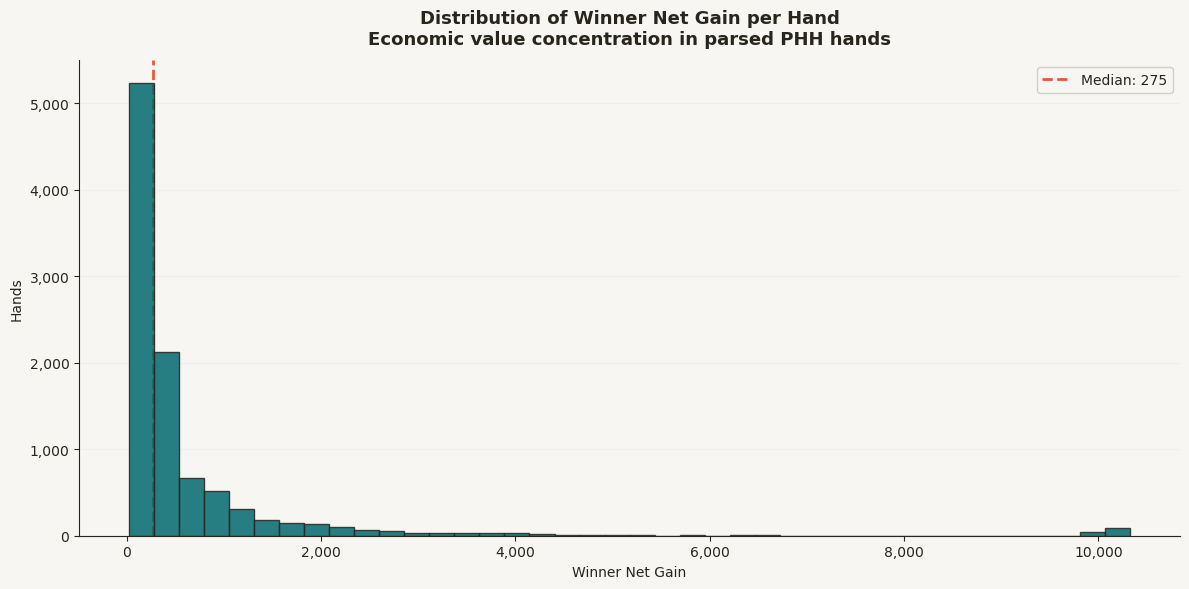

In [27]:
plot_df = winner_value_df.dropna(subset=["max_winner_net"]).copy()

# Remove extreme outliers for readable chart
upper = plot_df["max_winner_net"].quantile(0.99)
plot_trim = plot_df[plot_df["max_winner_net"] <= upper].copy()

fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(
    plot_trim["max_winner_net"],
    bins=40,
    color=TEAL,
    edgecolor=TEXT,
    alpha=0.85,
    zorder=3
)

ax.axvline(
    plot_trim["max_winner_net"].median(),
    color=RED,
    linestyle="--",
    linewidth=2,
    label=f"Median: {plot_trim['max_winner_net'].median():,.0f}"
)

ax.set_title(
    "Distribution of Winner Net Gain per Hand\n"
    "Economic value concentration in parsed PHH hands",
    fontsize=13,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("Winner Net Gain")
ax.set_ylabel("Hands")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax.grid(axis="y", alpha=0.25, color=GRID, zorder=0)
ax.legend(framealpha=0.9)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("phh_winner_net_gain_distribution.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

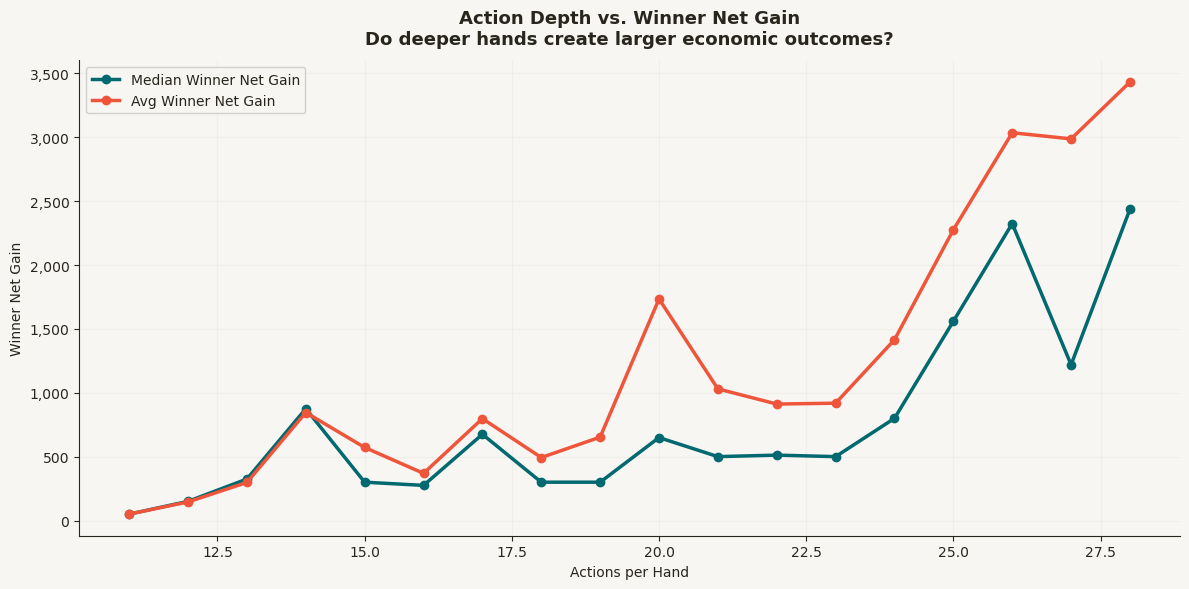

,num_actions,hands,avg_winner_net,median_winner_net,avg_bets_raises,showdown_rate
0,11,1058,50.000000,50.0,0.000000,0.0
1,12,2522,145.459952,150.0,1.000000,0.0
2,13,847,298.060213,325.0,1.866588,0.0
3,14,200,845.470000,875.0,2.685000,0.0
4,15,187,571.962567,300.0,2.005348,0.0


In [28]:
plot_df = winner_value_df.dropna(subset=["num_actions", "max_winner_net"]).copy()

# Trim extreme winner-net outliers for readability
upper = plot_df["max_winner_net"].quantile(0.99)
plot_trim = plot_df[plot_df["max_winner_net"] <= upper].copy()

action_value_summary = (
    plot_trim
    .groupby("num_actions", as_index=False)
    .agg(
        hands=("file", "count"),
        avg_winner_net=("max_winner_net", "mean"),
        median_winner_net=("max_winner_net", "median"),
        avg_bets_raises=("num_bets_raises", "mean"),
        showdown_rate=("showdown_like_hand", "mean")
    )
)

# Keep action counts with enough hands
action_value_summary = action_value_summary[action_value_summary["hands"] >= 20]

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    action_value_summary["num_actions"],
    action_value_summary["median_winner_net"],
    marker="o",
    linewidth=2.5,
    color=TEAL,
    label="Median Winner Net Gain",
    zorder=3
)

ax.plot(
    action_value_summary["num_actions"],
    action_value_summary["avg_winner_net"],
    marker="o",
    linewidth=2.5,
    color=RED,
    label="Avg Winner Net Gain",
    zorder=3
)

ax.set_title(
    "Action Depth vs. Winner Net Gain\n"
    "Do deeper hands create larger economic outcomes?",
    fontsize=13,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("Actions per Hand")
ax.set_ylabel("Winner Net Gain")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax.grid(alpha=0.25, color=GRID, zorder=0)
ax.legend(framealpha=0.9)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("phh_action_depth_vs_winner_net_gain.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

action_value_summary.head()

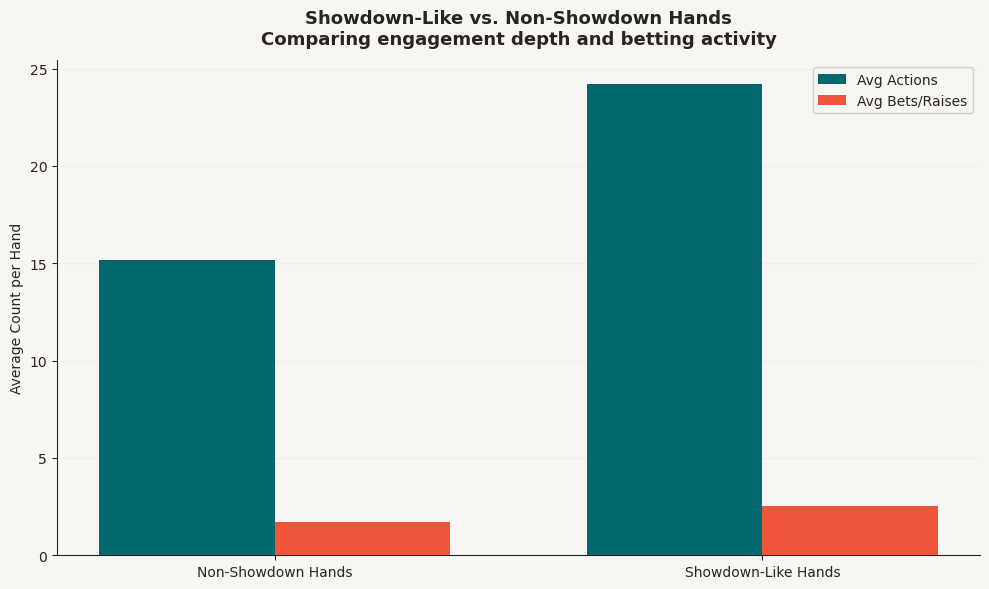

,showdown_like_hand,hands,avg_actions,avg_bets_raises,median_winner_net,avg_winner_net,avg_bet_raise_rate,label
0,False,8374,15.152615,1.720325,250.0,3280.660019,0.105330,Non-Showdown Hands
1,True,1673,24.202630,2.536760,819.0,33727.982666,0.104371,Showdown-Like Hands


In [29]:
showdown_value_summary = (
    winner_value_df
    .dropna(subset=["max_winner_net"])
    .groupby("showdown_like_hand", as_index=False)
    .agg(
        hands=("file", "count"),
        avg_actions=("num_actions", "mean"),
        avg_bets_raises=("num_bets_raises", "mean"),
        median_winner_net=("max_winner_net", "median"),
        avg_winner_net=("max_winner_net", "mean"),
        avg_bet_raise_rate=("bet_raise_rate", "mean")
    )
)

showdown_value_summary["label"] = np.where(
    showdown_value_summary["showdown_like_hand"],
    "Showdown-Like Hands",
    "Non-Showdown Hands"
)

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(showdown_value_summary))
width = 0.36

ax.bar(
    x - width / 2,
    showdown_value_summary["avg_actions"],
    width,
    label="Avg Actions",
    color=TEAL,
    zorder=3
)

ax.bar(
    x + width / 2,
    showdown_value_summary["avg_bets_raises"],
    width,
    label="Avg Bets/Raises",
    color=RED,
    zorder=3
)

ax.set_xticks(x)
ax.set_xticklabels(showdown_value_summary["label"])

ax.set_title(
    "Showdown-Like vs. Non-Showdown Hands\n"
    "Comparing engagement depth and betting activity",
    fontsize=13,
    fontweight="bold",
    pad=12
)

ax.set_ylabel("Average Count per Hand")
ax.grid(axis="y", alpha=0.25, color=GRID, zorder=0)
ax.legend(framealpha=0.9)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("phh_showdown_vs_non_showdown_engagement.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

showdown_value_summary

### Interpretation: Outcome Intensity

The showdown-like versus non-showdown comparison strengthens the product-experience story. Showdown-like hands average about 24.2 actions compared with about 15.2 for non-showdown hands, and their median winner net gain is also higher. That suggests deeper resolution states tend to coincide with larger observable value swings.

The average winner-net value is much larger for showdown-like hands, but that number should be treated carefully because raw values can be affected by source, stake scale, and outliers. The median is the safer read here, and the normalized outcome section that follows is a better way to compare intensity within the main Pluribus population.

**Commercial read:** operators care about the distribution of experience intensity. A healthy ecosystem likely needs both quick, accessible interactions and a smaller set of higher-intensity moments that create suspense, volatility, and memorable user experiences.


## Contested Chips as a Pot-Size Proxy

The existing outcome analysis identifies winners and net changes. A more commercial version names the key business proxy directly: how many chips were actually transferred to winning players in a hand.

Here, `chips_contested_proxy` is calculated from positive stack changes. It is not rake, and public PHH data does not expose platform revenue. But it is a reasonable observable proxy for value-swing intensity, which is the hand-level behavior most connected to rake opportunity, volatility, and high-salience contest moments.

In [30]:
winner_value_df["chips_contested_proxy"] = winner_value_df["chips_contested_proxy"].fillna(
    winner_value_df["total_positive_net"]
)

def concentration_share(series, top_share):
    values = series.dropna().sort_values(ascending=False).reset_index(drop=True)
    if len(values) == 0 or values.sum() == 0:
        return np.nan
    n = max(1, int(len(values) * top_share))
    return values.iloc[:n].sum() / values.sum()

pot_size_df = winner_value_df.dropna(subset=["chips_contested_proxy"]).copy()
pot_size_df = pot_size_df[pot_size_df["chips_contested_proxy"] > 0].copy()
pot_size_df["source_type_detailed"] = pot_size_df["source_folder"].apply(source_type_detailed_from_folder)

pot_concentration_summary = pd.DataFrame([
    {
        "top_hand_share": f"Top {pct:.0%}",
        "chips_contested_share": concentration_share(pot_size_df["chips_contested_proxy"], pct),
    }
    for pct in [0.01, 0.05, 0.10, 0.20]
])

pot_size_summary = (
    pot_size_df
    .groupby("source_type_detailed", as_index=False)
    .agg(
        hands=("file", "count"),
        median_chips_contested=("chips_contested_proxy", "median"),
        p90_chips_contested=("chips_contested_proxy", lambda s: s.quantile(0.90)),
        avg_chips_contested=("chips_contested_proxy", "mean"),
        total_chips_contested=("chips_contested_proxy", "sum"),
    )
    .sort_values("hands", ascending=False)
)

display(pot_size_summary)
display(pot_concentration_summary)


,source_type_detailed,hands,median_chips_contested,p90_chips_contested,avg_chips_contested,total_chips_contested
0,Pluribus (AI benchmark),9966,275.0,1438.5,688.342565,6860022.0
1,WSOP mixed-game sample,81,650000.0,2200000.0,956543.209877,77480000.0


,top_hand_share,chips_contested_share
0,Top 1%,0.921239
1,Top 5%,0.950480
2,Top 10%,0.962807
3,Top 20%,0.975824


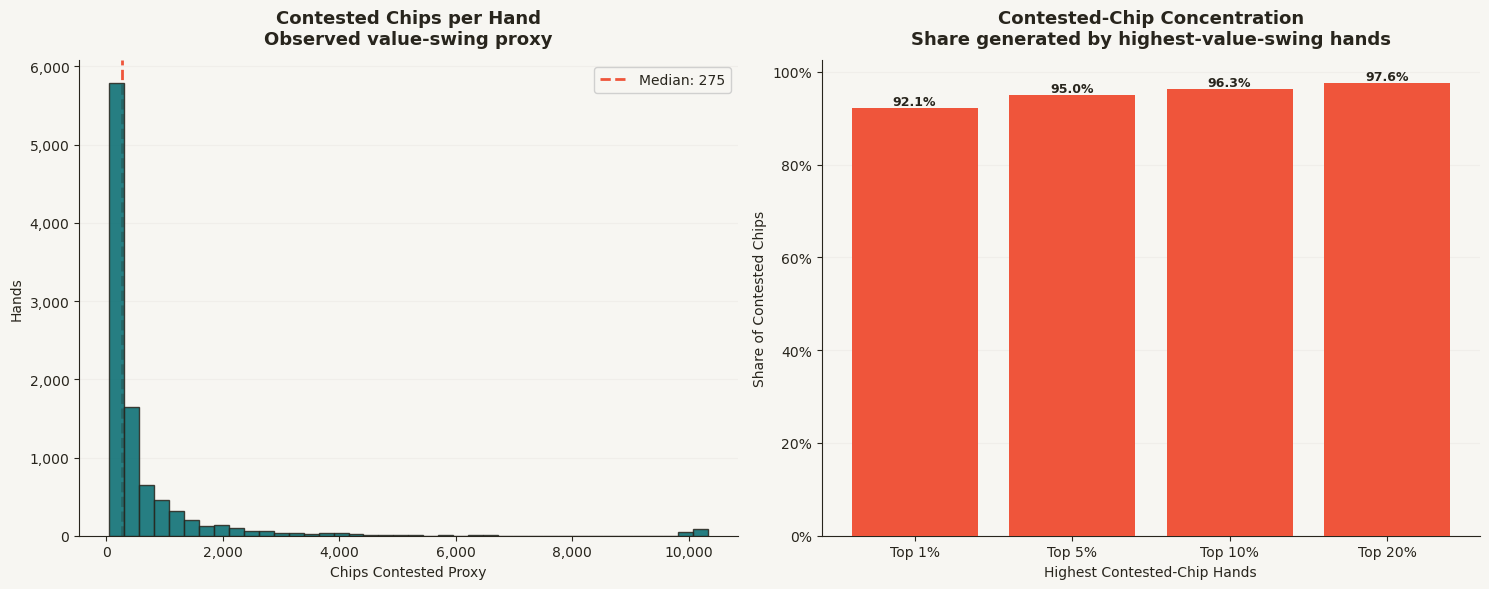

In [31]:
plot_df = pot_size_df.copy()
upper = plot_df["chips_contested_proxy"].quantile(0.99)
plot_trim = plot_df[plot_df["chips_contested_proxy"] <= upper].copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
ax.hist(
    plot_trim["chips_contested_proxy"],
    bins=40,
    color=TEAL,
    edgecolor=TEXT,
    alpha=0.85,
    zorder=3,
)
ax.axvline(
    plot_trim["chips_contested_proxy"].median(),
    color=RED,
    linestyle="--",
    linewidth=2,
    label=f"Median: {plot_trim['chips_contested_proxy'].median():,.0f}",
)
ax.set_title("Contested Chips per Hand\nObserved value-swing proxy", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Chips Contested Proxy")
ax.set_ylabel("Hands")
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax.grid(axis="y", alpha=0.25, color=GRID, zorder=0)
ax.legend(framealpha=0.9)
ax.spines[["top", "right"]].set_visible(False)

ax = axes[1]
bars = ax.bar(
    pot_concentration_summary["top_hand_share"],
    pot_concentration_summary["chips_contested_share"] * 100,
    color=RED,
    zorder=3,
)
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )
ax.set_title("Contested-Chip Concentration\nShare generated by highest-value-swing hands", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Highest Contested-Chip Hands")
ax.set_ylabel("Share of Contested Chips")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(axis="y", alpha=0.25, color=GRID, zorder=0)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("phh_chips_contested_distribution.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()


### Interpretation: Contested Chips

This is the most direct commercial translation of the stack-change data. A small number of hands can account for a disproportionate share of contested chips, which means the economic experience of the ecosystem is not evenly distributed across hand volume.

That matters for product analytics because hand count alone can understate the importance of deeper, higher-swing interactions. In a real platform dataset, this same metric would be connected to rake, session depth, player tenure, and responsible gaming monitoring. In this public PHH dataset, it remains a proxy, so the conclusion is about value-swing concentration rather than actual revenue.

## Normalized Outcome Intensity

            Raw winner net gain can be misleading when sources use different stakes or chip scales. This section normalizes outcome size by total starting stack so the metric reads as a share of available contest value.

            This is a better commercial measure of **value swing intensity** than raw chip or currency amounts.


In [32]:
winner_value_df["total_starting_stack"] = winner_value_df["starting_stacks"].apply(
    lambda stacks: sum(x for x in stacks if isinstance(x, (int, float)))
    if isinstance(stacks, list)
    else np.nan
)

winner_value_df["winner_net_gain_pct_of_starting_stack"] = (
    winner_value_df["max_winner_net"] / winner_value_df["total_starting_stack"]
)

outcome_intensity_df = winner_value_df.dropna(
    subset=["winner_net_gain_pct_of_starting_stack", "max_winner_net"]
).copy()

# Use Pluribus as the main comparable population because it represents nearly all hands
# and has a consistent six-player no-limit format.
outcome_intensity_df["source_folder"] = outcome_intensity_df["file"].apply(lambda x: source_folder(Path(x)))
pluribus_outcome_df = outcome_intensity_df[outcome_intensity_df["source_folder"].eq("pluribus")].copy()

outcome_intensity_summary = pd.DataFrame([{
    "hands": len(pluribus_outcome_df),
    "median_outcome_intensity": pluribus_outcome_df["winner_net_gain_pct_of_starting_stack"].median(),
    "p75_outcome_intensity": pluribus_outcome_df["winner_net_gain_pct_of_starting_stack"].quantile(0.75),
    "p90_outcome_intensity": pluribus_outcome_df["winner_net_gain_pct_of_starting_stack"].quantile(0.90),
    "p95_outcome_intensity": pluribus_outcome_df["winner_net_gain_pct_of_starting_stack"].quantile(0.95),
    "p99_outcome_intensity": pluribus_outcome_df["winner_net_gain_pct_of_starting_stack"].quantile(0.99),
}])

outcome_intensity_summary.T


,0
hands,9966.000000
median_outcome_intensity,0.004583
p75_outcome_intensity,0.009583
p90_outcome_intensity,0.023975
p95_outcome_intensity,0.041667
p99_outcome_intensity,0.168333


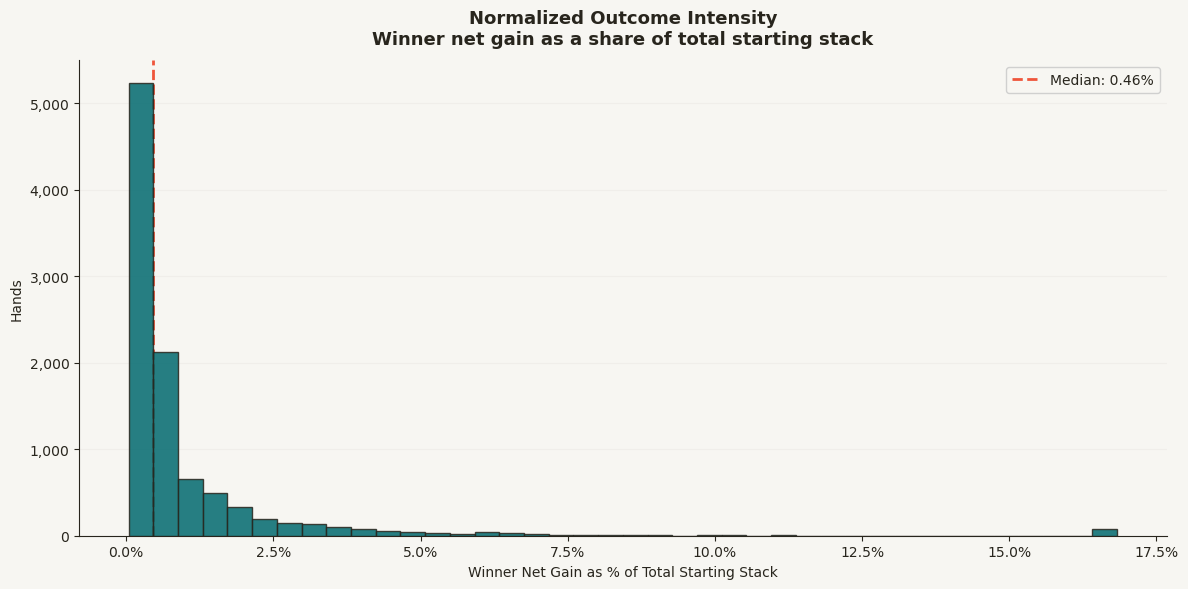

In [33]:
plot_df = pluribus_outcome_df.copy()
upper = plot_df["winner_net_gain_pct_of_starting_stack"].quantile(0.99)
plot_trim = plot_df[plot_df["winner_net_gain_pct_of_starting_stack"] <= upper].copy()

fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(
    plot_trim["winner_net_gain_pct_of_starting_stack"] * 100,
    bins=40,
    color=TEAL,
    edgecolor=TEXT,
    alpha=0.85,
    zorder=3,
)

ax.axvline(
    plot_trim["winner_net_gain_pct_of_starting_stack"].median() * 100,
    color=RED,
    linestyle="--",
    linewidth=2,
    label=f"Median: {plot_trim['winner_net_gain_pct_of_starting_stack'].median() * 100:.2f}%",
)

ax.set_title(
    "Normalized Outcome Intensity\n"
    "Winner net gain as a share of total starting stack",
    fontsize=13,
    fontweight="bold",
    pad=12,
)

ax.set_xlabel("Winner Net Gain as % of Total Starting Stack")
ax.set_ylabel("Hands")
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax.grid(axis="y", alpha=0.25, color=GRID, zorder=0)
ax.legend(framealpha=0.9)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("phh_normalized_outcome_intensity.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()


### Interpretation: Normalized Outcome Intensity

Normalizing winner net gain by total starting stack makes the outcome metric more defensible. Instead of asking how many chips changed hands, the notebook asks how large the value swing was relative to the contest environment.

In the main Pluribus population, the median outcome intensity is about 0.46% of total starting stack, while the 90th percentile is about 2.4%, the 95th percentile about 4.2%, and the 99th percentile about 16.8%. That shape matters: most hands are modest, but the upper tail is meaningfully larger.

**Commercial read:** normalized outcome intensity works like a volatility KPI. It helps separate ordinary interaction from the smaller number of hands that create larger economic swings and potentially more memorable engagement moments.


## Outcome Concentration

            A product analytics team may care not only about the average hand, but also whether a small share of interactions creates a large share of the economic intensity. This is similar to concentration analysis in marketplaces, contests, and engagement ecosystems.


In [34]:
def concentration_share(series, top_share):
    values = series.dropna().sort_values(ascending=False).reset_index(drop=True)
    if len(values) == 0 or values.sum() == 0:
        return np.nan
    n = max(1, int(len(values) * top_share))
    return values.iloc[:n].sum() / values.sum()

concentration_summary = pd.DataFrame([
    {
        "top_hand_share": "Top 1%",
        "outcome_intensity_share": concentration_share(
            pluribus_outcome_df["winner_net_gain_pct_of_starting_stack"], 0.01
        ),
    },
    {
        "top_hand_share": "Top 5%",
        "outcome_intensity_share": concentration_share(
            pluribus_outcome_df["winner_net_gain_pct_of_starting_stack"], 0.05
        ),
    },
    {
        "top_hand_share": "Top 10%",
        "outcome_intensity_share": concentration_share(
            pluribus_outcome_df["winner_net_gain_pct_of_starting_stack"], 0.10
        ),
    },
    {
        "top_hand_share": "Top 20%",
        "outcome_intensity_share": concentration_share(
            pluribus_outcome_df["winner_net_gain_pct_of_starting_stack"], 0.20
        ),
    },
])

concentration_summary


,top_hand_share,outcome_intensity_share
0,Top 1%,0.150327
1,Top 5%,0.421274
2,Top 10%,0.558974
3,Top 20%,0.710462


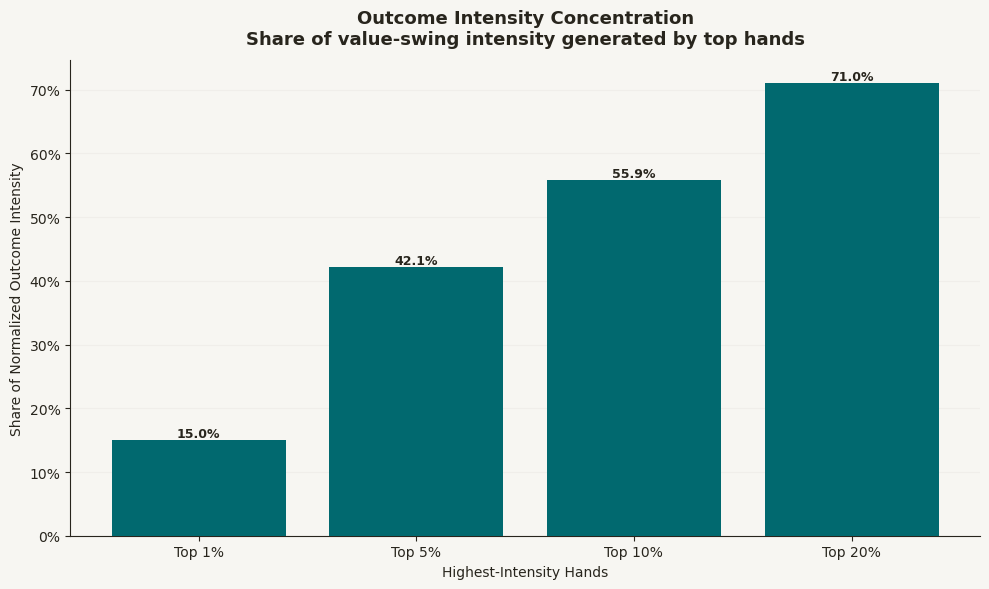

In [35]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    concentration_summary["top_hand_share"],
    concentration_summary["outcome_intensity_share"] * 100,
    color=TEAL,
    zorder=3,
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )

ax.set_title(
    "Outcome Intensity Concentration\n"
    "Share of value-swing intensity generated by top hands",
    fontsize=13,
    fontweight="bold",
    pad=12,
)

ax.set_xlabel("Highest-Intensity Hands")
ax.set_ylabel("Share of Normalized Outcome Intensity")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(axis="y", alpha=0.25, color=GRID, zorder=0)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("phh_outcome_intensity_concentration.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()


### Interpretation: Outcome Concentration

The concentration chart is one of the clearest commercial insights in the notebook. The top 1% of hands account for about 15% of normalized outcome intensity, the top 5% account for about 42%, the top 10% account for about 56%, and the top 20% account for about 71%.

That pattern is familiar in marketplace, gaming, and product analytics: a minority of events often drives a disproportionate share of intensity, value movement, or memorable user experience. The point is not that those hands are "better." The point is that the product experience has a long-tail intensity structure.

**Commercial read:** this gives the project a strong ecosystem-analysis angle. It shows how an analyst can move from raw event logs to questions about concentration, volatility, and the distribution of user experience across a contest environment.


## Anonymized Participant Behavior Profiles

            This section demonstrates how the same event-log workflow could support participant segmentation. The goal is not to rank poker skill. The goal is to show how observable actions can be converted into behavioral profiles.

            Because this dataset contains named example participants, the display below anonymizes them before presentation.


In [36]:
participant_rows = []

for path in tqdm([p for p in phh_files if source_folder(p) == "pluribus"], desc="Profiling participants"):
    try:
        participant_rows.extend(parse_participant_rows(path))
    except Exception:
        pass

participant_df = pd.DataFrame(participant_rows)

# Convert numeric columns to proper data types and handle non-numeric values
numeric_columns = ["active_hand", "actions", "bets_raises", "folds", "won_hand", "net_change"]
for col in numeric_columns:
    if col in participant_df.columns:
        # Convert to numeric, replacing non-numeric values with NaN
        participant_df[col] = pd.to_numeric(participant_df[col], errors='coerce')

participant_profile = (
    participant_df
    .groupby("participant", as_index=False)
    .agg(
        hands=("file", "count"),
        active_rate=("active_hand", "mean"),
        avg_actions=("actions", "mean"),
        high_commitment_action_rate=("bets_raises", lambda s: (s > 0).mean()),
        fold_hand_rate=("folds", lambda s: (s > 0).mean()),
        win_rate=("won_hand", "mean"),
        total_net_change=("net_change", "sum"),
        median_net_change=("net_change", "median"),
    )
)

anon_map = {
    participant: f"Participant {i + 1:02d}"
    for i, participant in enumerate(sorted(participant_profile["participant"]))
}

participant_display = participant_profile.copy()
participant_display["participant"] = participant_display["participant"].map(anon_map)
participant_display = participant_display.sort_values("high_commitment_action_rate", ascending=False)

# Only round columns that exist and are numeric
for col in [
    "active_rate",
    "avg_actions", 
    "high_commitment_action_rate",
    "fold_hand_rate",
    "win_rate",
    "median_net_change",
]:
    if col in participant_display.columns:
        # Ensure the column is numeric before rounding
        participant_display[col] = pd.to_numeric(participant_display[col], errors='coerce').round(3)

participant_display


Profiling participants:   0%|          | 0/10000 [00:00<?, ?it/s]

Profiling participants:   2%|▏         | 186/10000 [00:00<00:05, 1855.92it/s]

Profiling participants:   4%|▍         | 400/10000 [00:00<00:04, 2019.17it/s]

Profiling participants:   6%|▌         | 602/10000 [00:00<00:04, 1985.20it/s]

Profiling participants:   8%|▊         | 839/10000 [00:00<00:04, 2133.45it/s]

...

Profiling participants:  95%|█████████▌| 9517/10000 [00:04<00:00, 2017.00it/s]

Profiling participants:  97%|█████████▋| 9725/10000 [00:04<00:00, 1843.73it/s]

Profiling participants:  99%|█████████▉| 9933/10000 [00:04<00:00, 1905.22it/s]

Profiling participants: 100%|██████████| 10000/10000 [00:04<00:00, 2232.17it/s]

,participant,hands,active_rate,avg_actions,high_commitment_action_rate,fold_hand_rate,win_rate,total_net_change,median_net_change
3,Participant 04,488,0.973,1.652,0.260,0.775,0.189,-28312.0,0.0
7,Participant 08,9121,0.979,1.646,0.234,0.778,0.192,150182.0,0.0
0,Participant 01,6713,0.985,1.541,0.234,0.789,0.177,-23097.0,0.0
2,Participant 03,5510,0.983,1.558,0.220,0.799,0.175,66718.0,0.0
4,Participant 05,1365,0.974,1.531,0.216,0.799,0.162,4597.0,0.0
13,Participant 14,10000,0.984,1.517,0.214,0.801,0.169,-71214.0,0.0
10,Participant 11,6055,0.982,1.509,0.214,0.800,0.169,-16236.0,0.0
12,Participant 13,771,0.981,1.502,0.211,0.805,0.164,1839.0,0.0
1,Participant 02,2509,0.984,1.456,0.211,0.807,0.166,71825.0,0.0
5,Participant 06,1535,0.991,1.435,0.205,0.825,0.148,-28127.0,0.0


### Interpretation: Participant Profiles

The participant profile table shows how the same event-log approach can produce behavioral segmentation. The useful signals are relative differences in high-commitment action rate, fold frequency, win rate, average action count, and net outcome. The table is intentionally anonymized so it reads like a customer-behavior profile rather than a poker-player ranking.

The strongest interpretation is descriptive: participants do not all interact with the contest environment in the same way. Some appear more likely to take high-commitment actions; others show higher fold rates or lower win rates. Those differences are commercially relevant because they resemble the kinds of behavioral segments a gaming or fantasy operator might track.

The caveat is equally important. This public dataset does not include account tenure, acquisition channel, deposits, session history, promotion exposure, or retention outcomes, so the table should not be treated as causal. It is a demonstration of segmentation workflow, not proof of player quality.

**Commercial read:** with richer internal data, these profiles could be joined to lifecycle metrics and retention outcomes to understand whether certain behavior patterns correspond to churn risk, engagement quality, monetization, or product fit.


## Explicit Obfuscation Test

            This validation section checks whether show/muck-style resolution actually exposes cards. It is intentionally included to prevent overclaiming.


In [37]:
obf_rows = [
    parse_obfuscation_resolution(path)
    for path in tqdm(phh_files, desc="Checking obfuscation vs resolution")
]
obf_df = pd.DataFrame(obf_rows)

print(obf_df.shape)
display(obf_df.head())


Checking obfuscation vs resolution:   0%|          | 0/10088 [00:00<?, ?it/s]

Checking obfuscation vs resolution:   1%|▏         | 145/10088 [00:00<00:06, 1449.47it/s]

Checking obfuscation vs resolution:   3%|▎         | 290/10088 [00:00<00:07, 1299.02it/s]

Checking obfuscation vs resolution:   5%|▍         | 486/10088 [00:00<00:06, 1579.11it/s]

Checking obfuscation vs resolution:   6%|▋         | 655/10088 [00:00<00:05, 1620.70it/s]

...

Checking obfuscation vs resolution:  98%|█████████▊| 9900/10088 [00:09<00:00, 971.68it/s]

Checking obfuscation vs resolution:  99%|█████████▉| 10005/10088 [00:09<00:00, 985.58it/s]

Checking obfuscation vs resolution: 100%|██████████| 10088/10088 [00:10<00:00, 996.73it/s]

(10088, 23)


,file,filename,parse_success,variant,num_players,num_actions,known_card_count,unknown_char_count,has_known_cards,has_any_obfuscation,...,sm_actions,sm_known_actions,sm_obfuscated_actions,sm_no_card_actions,has_sm,resolution_type,last_action,last_action_code,last_non_deal_action,last_non_deal_code
0,C:\Users\J1999\Downloads\poker-hand-histories\...,alice-carol-wikipedia.phh,True,FB,4,36,0,64,False,True,...,2,0,0,2,True,Show/muck with no card text,p2 sm 3s5d7c8h,sm,p2 sm 3s5d7c8h,sm
1,C:\Users\J1999\Downloads\poker-hand-histories\...,antonius-blom-2009.phh,True,PO,2,16,2,0,True,False,...,2,0,0,2,True,Show/muck with no card text,d db 9c,db,p2 sm 6d9s7d8h,sm
2,C:\Users\J1999\Downloads\poker-hand-histories\...,arieh-yockey-2019.phh,True,F2L3D,4,26,4,20,True,True,...,2,0,0,2,True,Show/muck with no card text,p4 sm 2h4d7c5c3c,sm,p4 sm 2h4d7c5c3c,sm
3,C:\Users\J1999\Downloads\poker-hand-histories\...,dwan-ivey-2009.phh,True,NT,3,18,2,4,True,True,...,2,0,0,2,True,Show/muck with no card text,d db jh,db,p3 sm 7h6h,sm
4,C:\Users\J1999\Downloads\poker-hand-histories\...,phua-xuan-2019.phh,True,NS,6,20,2,0,True,False,...,2,0,0,2,True,Show/muck with no card text,d db ts,db,p3 sm qhqd,sm


In [38]:
print("Parse success:")
display(obf_df["parse_success"].value_counts(dropna=False))

print("\nResolution type counts:")
resolution_summary = (
    obf_df
    .groupby("resolution_type", as_index=False)
    .agg(hands=("file", "count"))
    .sort_values("hands", ascending=False)
)

resolution_summary["share"] = resolution_summary["hands"] / resolution_summary["hands"].sum()
display(resolution_summary)

print("\nShow/muck card visibility summary:")
sm_summary = pd.DataFrame([{
    "total_hands": len(obf_df),
    "hands_with_show_muck": int(obf_df["has_sm"].sum()),
    "hands_with_known_show_muck_cards": int((obf_df["sm_known_actions"] > 0).sum()),
    "hands_with_obfuscated_show_muck_cards": int((obf_df["sm_obfuscated_actions"] > 0).sum()),
    "hands_with_show_muck_but_no_card_text": int((obf_df["sm_no_card_actions"] > 0).sum()),
    "hands_with_any_obfuscation": int(obf_df["has_any_obfuscation"].sum()),
    "hands_with_known_cards_anywhere": int(obf_df["has_known_cards"].sum()),
}])

display(sm_summary.T)

print("\nLast non-deal action codes:")
display(obf_df["last_non_deal_code"].value_counts(dropna=False).head(20))

Parse success:


parse_success
True    10088
Name: count, dtype: int64


Resolution type counts:


,resolution_type,hands,share
0,No show/muck activity,8374,0.830095
1,Show/muck with no card text,1714,0.169905



Show/muck card visibility summary:


,0
total_hands,10088
hands_with_show_muck,1714
hands_with_known_show_muck_cards,0
hands_with_obfuscated_show_muck_cards,0
hands_with_show_muck_but_no_card_text,1714
hands_with_any_obfuscation,19
hands_with_known_cards_anywhere,3910



Last non-deal action codes:


last_non_deal_code
f     8374
sm    1714
Name: count, dtype: int64

In [39]:
no_sm = (obf_df["resolution_type"] == "No show/muck activity").sum()
sm_obf = (obf_df["resolution_type"] == "Show/muck with obfuscated cards").sum()
sm_known = (obf_df["resolution_type"] == "Show/muck with known cards").sum()
sm_no_text = (obf_df["resolution_type"] == "Show/muck with no card text").sum()

print(f"No show/muck activity: {no_sm:,} hands ({no_sm / len(obf_df):.1%})")
print(f"Show/muck with known cards: {sm_known:,} hands ({sm_known / len(obf_df):.1%})")
print(f"Show/muck with obfuscated cards: {sm_obf:,} hands ({sm_obf / len(obf_df):.1%})")
print(f"Show/muck with no card text: {sm_no_text:,} hands ({sm_no_text / len(obf_df):.1%})")

if no_sm > sm_obf:
    print("\nMain issue: most hands simply do not have show/muck-style resolution activity.")
else:
    print("\nMain issue: show/muck happens, but card information is mostly obfuscated.")

No show/muck activity: 8,374 hands (83.0%)
Show/muck with known cards: 0 hands (0.0%)
Show/muck with obfuscated cards: 0 hands (0.0%)
Show/muck with no card text: 1,714 hands (17.0%)

Main issue: most hands simply do not have show/muck-style resolution activity.


### Interpretation: Explicit Obfuscation Test

The strict obfuscation test confirms the central limitation of the dataset. Of 10,088 parsed hands, 8,374 have no show/muck activity, and 1,714 have show/muck activity with no card text. In this stricter validation, there are no hands with known cards exposed through the terminal show/muck action.

This changes what the project should claim. The main issue is not simply that cards are hidden behind question marks. The larger issue is that most hands do not provide a card-disclosure event at all, and the hands that do reach show/muck-like resolution still do not reliably expose final card information.

**Commercial read:** this makes the project more credible. It shows that the analysis does not force unsupported strategy conclusions from incomplete data. Instead, it uses the reliable parts of the logs: action sequences, lifecycle depth, resolution paths, and outcome intensity.


## Commercial Takeaways

- Raw gameplay logs can be transformed into business-readable metrics for engagement depth, commitment intensity, street survival, lifecycle depth, resolution visibility, and outcome concentration.
- The project is pinned to Zenodo v2, while the public PHH reference repository currently documents v3. The core schema logic still applies, so the notebook explicitly validates source, variant, and game-structure fields instead of assuming all hands are the same format.
- The strongest analysis is action-based because observable actions are more reliable than private-card visibility in this PHH corpus.
- Pluribus is separated from WSOP/reference examples rather than folded into a generic "Other" bucket, which makes the behavioral comparisons more defensible.
- Street-level metrics show where interactions continue or resolve, turning hand histories into a product-style engagement funnel.
- Private-card and winner-card analysis should not be used for strategy claims because visibility is limited and partially obfuscated.
- Action-based segments create a practical framework for monitoring product experience across formats, cohorts, or time periods.
- Contest lifecycle depth adds a simple view of how far interactions progress before resolving.
- Contested chips and normalized outcome intensity avoid overreading raw chip values and show whether value swings are concentrated in a small share of hands.
- Participant profiles show how event logs can support behavioral segmentation, while remaining descriptive rather than causal.
- The project demonstrates a scalable analytics workflow for imperfect event data: audit coverage, define observable metrics, test data limitations, and communicate conclusions with appropriate caution.

## Recommended Next Steps

With richer internal gaming data, this workflow could be extended by joining hand-level behavior to player tenure, session frequency, buy-in level, contest type, acquisition channel, promotion exposure, rake, and retention outcomes. The largest public-data extension would be a separate HandHQ `.phhs` container analysis using `HandHistory.load_all()` to study session depth and stake-level behavior without mixing it into the current single-hand `.phh` population.